# Tourism Package Prediction — Advanced Machine Learning and MLOps

## Business Objective

The objective of this project is to develop a machine learning model that predicts whether a customer is likely to purchase the newly introduced Wellness Tourism Package.

The project will implement an end-to-end MLOps workflow covering:

- Data registration and ingestion
- Data cleaning and preprocessing
- Exploratory data analysis
- Feature engineering
- Model building and experimentation
- Model evaluation
- Model registration
- Application deployment
- GitHub Actions CI/CD
- MLOps workflow automation

## Project Overview

**Company:** Visit with Us

**Problem:** Predict whether a customer will purchase the Wellness Tourism Package.

**Target Variable:** `ProdTaken`

- `0` → Customer did not purchase
- `1` → Customer purchased

**Data Source:** Hugging Face Dataset Repository

**Repository:** `rashmikportfolio/tourism-package-prediction`

In [1]:
# Import libraries required for data handling and analysis

import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset directly from the Hugging Face repository

url = "https://huggingface.co/datasets/rashmikportfolio/tourism-package-prediction/resolve/main/tourism.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


## Data Understanding

Before performing data preprocessing, we inspect the structure, dimensions, data types, missing values, and statistical characteristics of the dataset.

In [4]:
df.shape

(4128, 21)

In [5]:
df.columns.tolist()

['Unnamed: 0',
 'CustomerID',
 'ProdTaken',
 'Age',
 'TypeofContact',
 'CityTier',
 'DurationOfPitch',
 'Occupation',
 'Gender',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'ProductPitched',
 'PreferredPropertyStar',
 'MaritalStatus',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'Designation',
 'MonthlyIncome']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 non-null   int64  
 2   ProdTaken                 4128 non-null   int64  
 3   Age                       4128 non-null   float64
 4   TypeofContact             4128 non-null   str    
 5   CityTier                  4128 non-null   int64  
 6   DurationOfPitch           4128 non-null   float64
 7   Occupation                4128 non-null   str    
 8   Gender                    4128 non-null   str    
 9   NumberOfPersonVisiting    4128 non-null   int64  
 10  NumberOfFollowups         4128 non-null   float64
 11  ProductPitched            4128 non-null   str    
 12  PreferredPropertyStar     4128 non-null   float64
 13  MaritalStatus             4128 non-null   str    
 14  NumberOfTrips      

In [7]:
df.isnull().sum()

Unnamed: 0                  0
CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,4128.0,2527.763808,1409.439133,0.0,1320.75,2603.5,3748.25,4887.0
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
ProdTaken,4128.0,0.193072,0.394757,0.0,0.00,0.0,0.00,1.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.00,3.0,4.00,22.0


## Exploratory Data Analysis

Exploratory data analysis is performed to understand the distribution of the target variable, identify patterns in customer characteristics, examine categorical variables, and detect potential data-quality issues before model development.

In [9]:
# Check the distribution of the target variable

df["ProdTaken"].value_counts()

ProdTaken
0    3331
1     797
Name: count, dtype: int64

In [10]:
# Check the target distribution in percentage terms

df["ProdTaken"].value_counts(normalize=True).mul(100).round(2)

ProdTaken
0    80.69
1    19.31
Name: proportion, dtype: float64

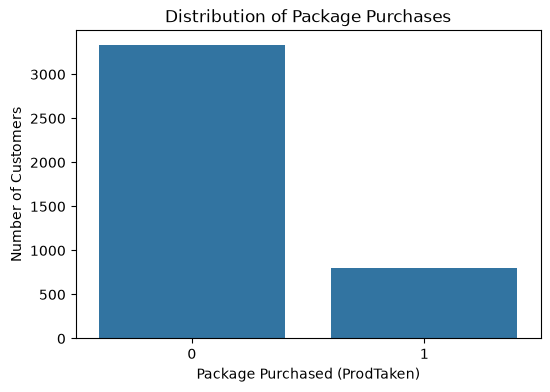

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="ProdTaken")
plt.title("Distribution of Package Purchases")
plt.xlabel("Package Purchased (ProdTaken)")
plt.ylabel("Number of Customers")
plt.show()

In [12]:
# Check for duplicate records

df.duplicated().sum()

np.int64(0)

In [13]:
# Check whether CustomerID is unique

df["CustomerID"].nunique()

4128

In [14]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include="str").columns

categorical_columns.tolist()

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [15]:
# Display unique values for each categorical variable

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


TypeofContact
TypeofContact
Self Enquiry       2918
Company Invited    1210
Name: count, dtype: int64

Occupation
Occupation
Salaried          1999
Small Business    1746
Large Business     381
Free Lancer          2
Name: count, dtype: int64

Gender
Gender
Male       2463
Female     1510
Fe Male     155
Name: count, dtype: int64

ProductPitched
ProductPitched
Basic           1615
Deluxe          1422
Standard         737
Super Deluxe     250
King             104
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married      1990
Divorced      789
Unmarried     682
Single        667
Name: count, dtype: int64

Designation
Designation
Executive         1615
Manager           1422
Senior Manager     737
AVP                250
VP                 104
Name: count, dtype: int64


In [16]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include="number").columns

numerical_columns.tolist()

['Unnamed: 0',
 'CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

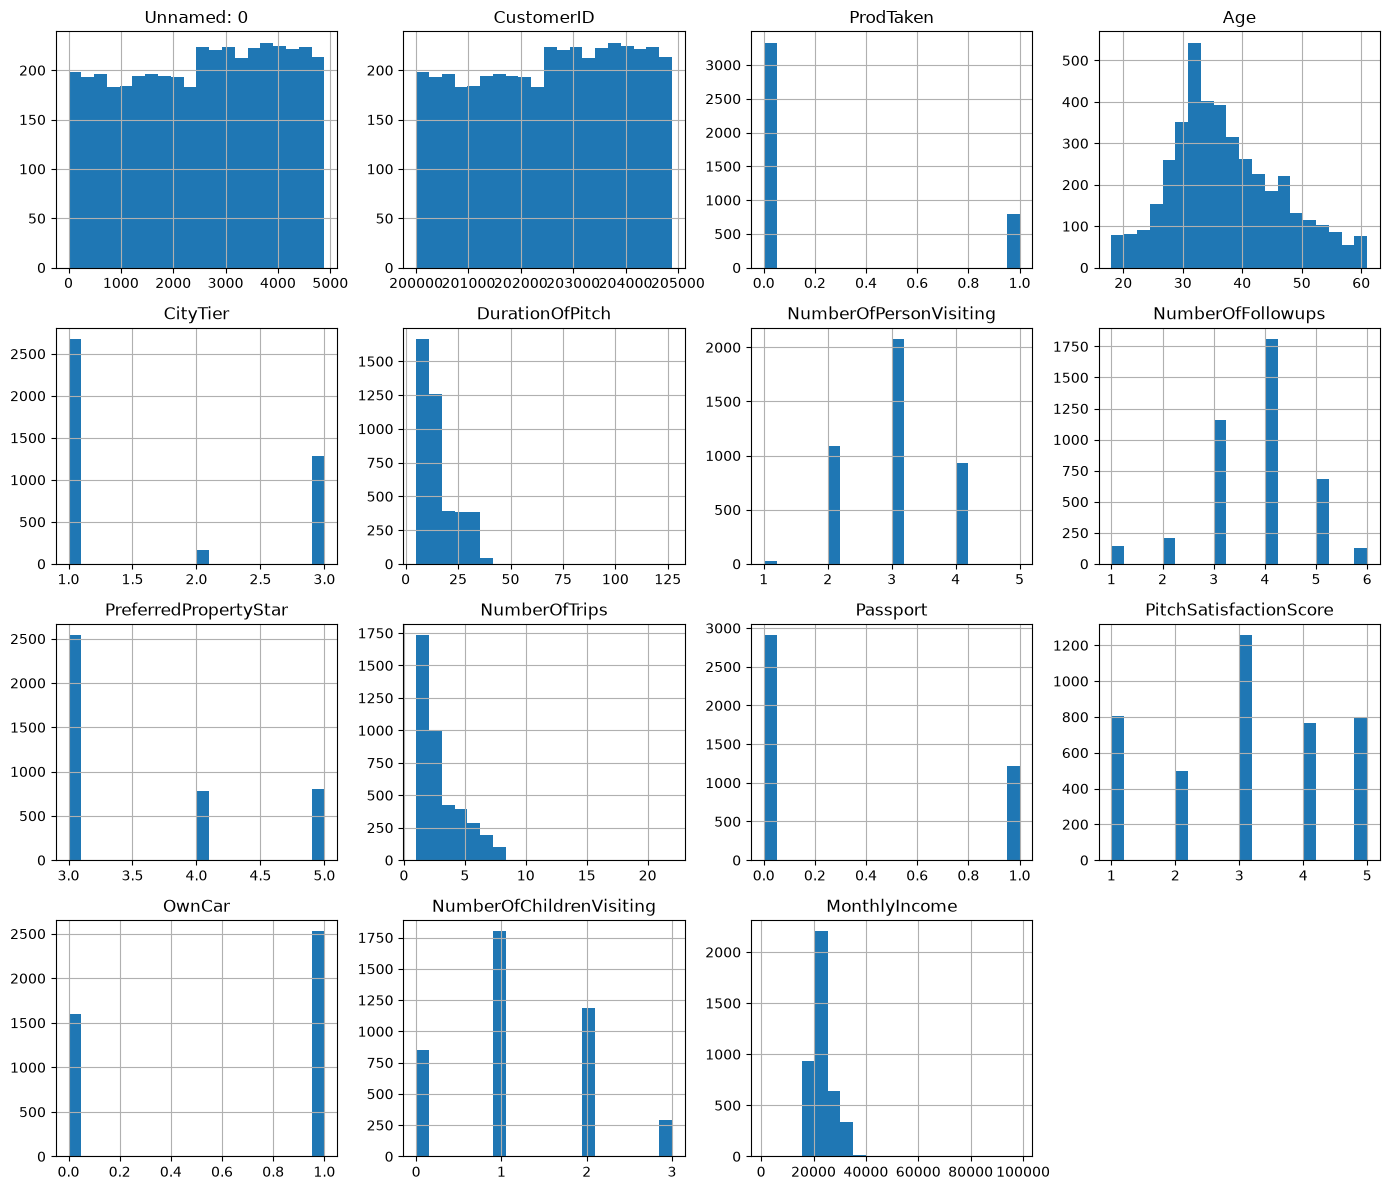

In [17]:
# Plot distributions of numerical variables

import matplotlib.pyplot as plt
import seaborn as sns

df[numerical_columns].hist(figsize=(14, 12), bins=20)

plt.tight_layout()
plt.show()

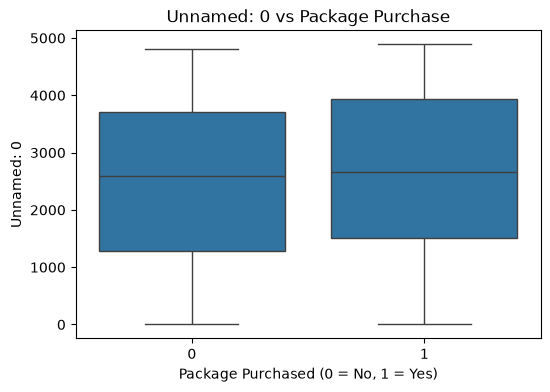

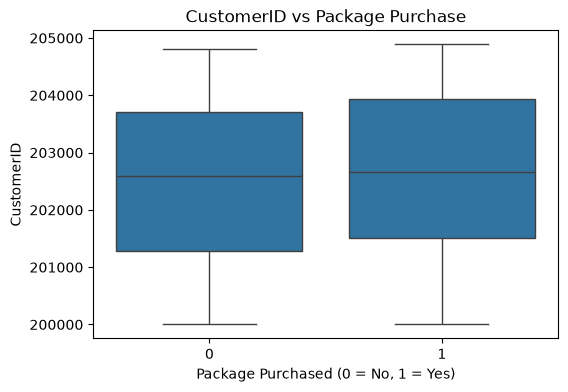

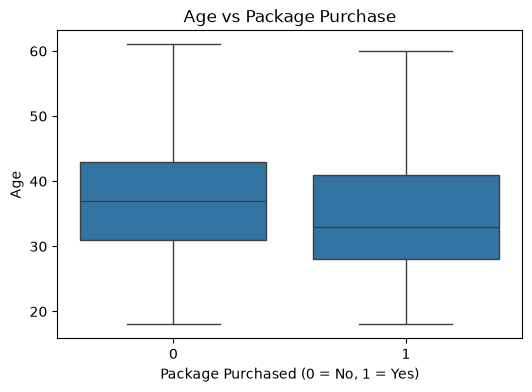

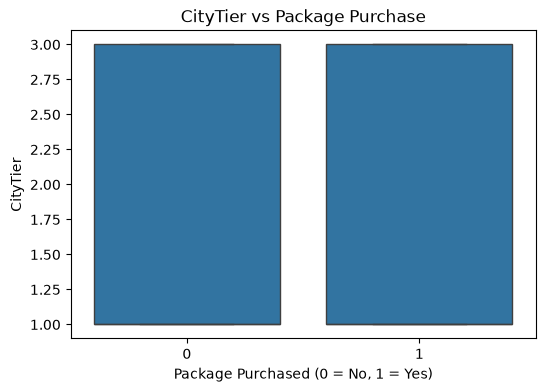

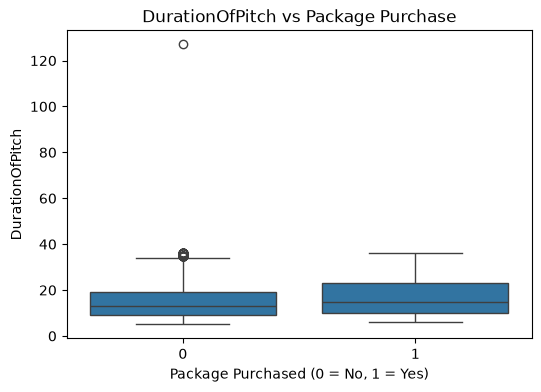

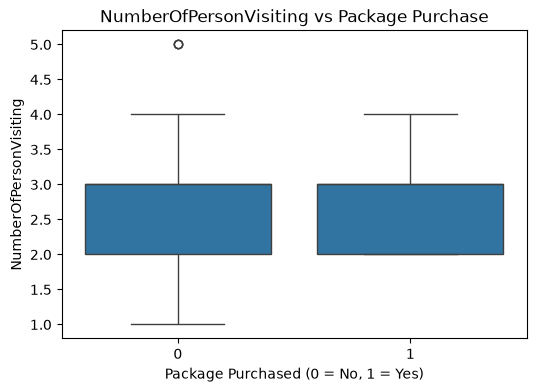

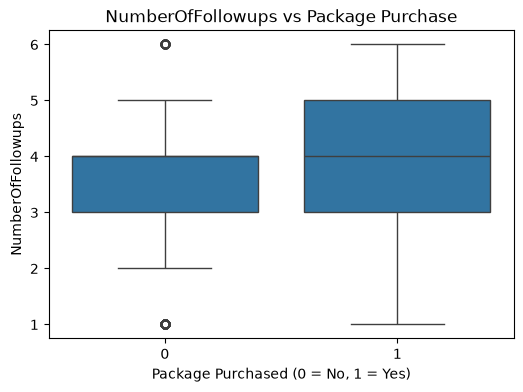

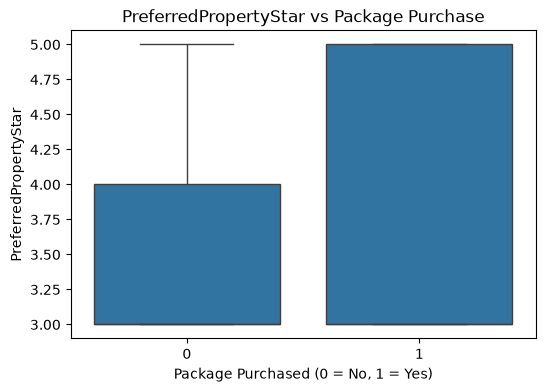

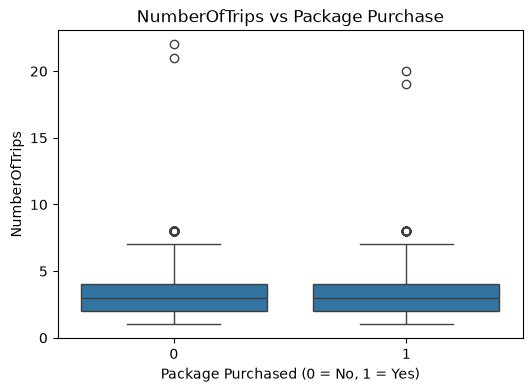

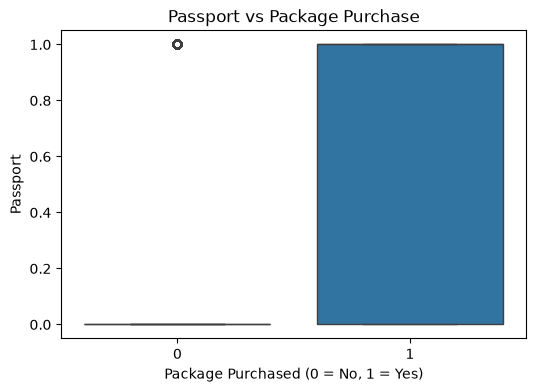

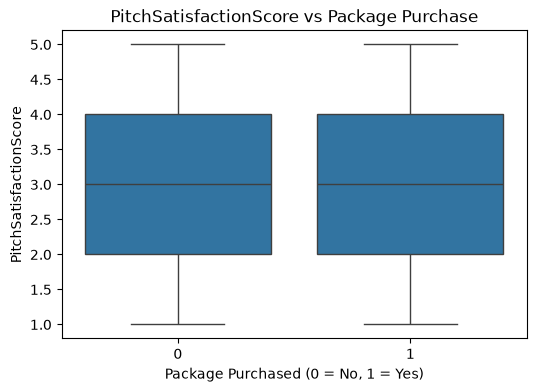

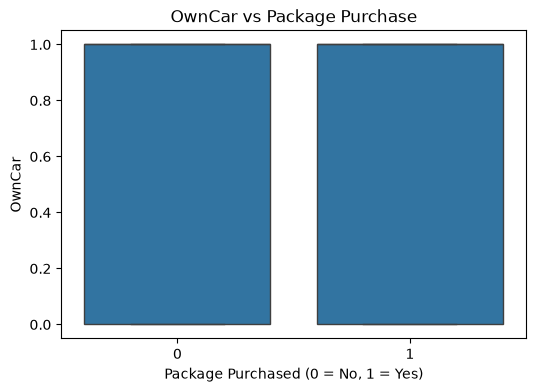

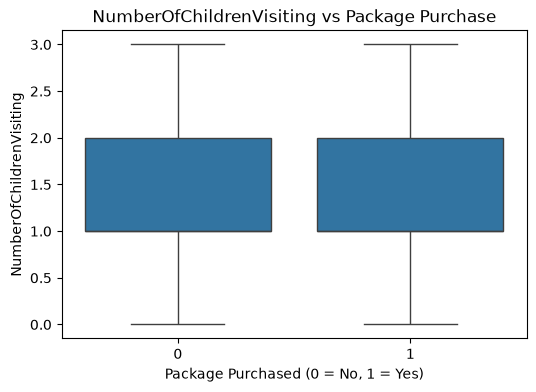

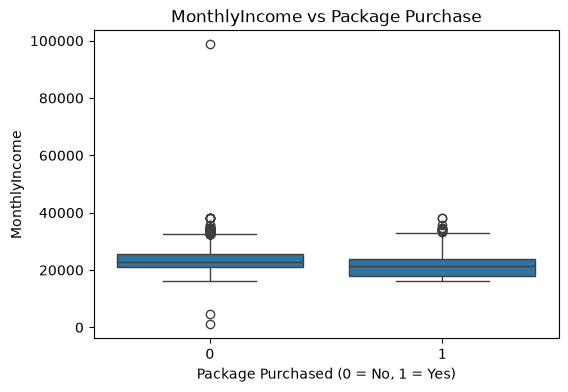

In [18]:
# Compare numerical variables across the target classes

for column in numerical_columns:
    if column != "ProdTaken":
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x="ProdTaken", y=column)
        plt.title(f"{column} vs Package Purchase")
        plt.xlabel("Package Purchased (0 = No, 1 = Yes)")
        plt.ylabel(column)
        plt.show()

In [19]:
# Examine package purchase rates across categorical variables

for column in categorical_columns:
    purchase_rate = pd.crosstab(
        df[column],
        df["ProdTaken"],
        normalize="index"
    ) * 100

    print(f"\n{column}")
    display(purchase_rate.round(2))


TypeofContact


ProdTaken,0,1
TypeofContact,,
Company Invited,77.27,22.73
Self Enquiry,82.11,17.89



Occupation


ProdTaken,0,1
Occupation,,
Free Lancer,0.00,100.00
Large Business,70.87,29.13
Salaried,82.04,17.96
Small Business,81.39,18.61



Gender


...

ProdTaken,0,1
ProductPitched,,
Basic,69.97,30.03
Deluxe,88.40,11.60
King,91.35,8.65
Standard,83.85,16.15
Super Deluxe,92.40,7.60



MaritalStatus


ProdTaken,0,1
MaritalStatus,,
Divorced,86.69,13.31
Married,85.78,14.22
Single,63.57,36.43
Unmarried,75.66,24.34



Designation


ProdTaken,0,1
Designation,,
AVP,92.40,7.60
Executive,69.97,30.03
Manager,88.40,11.60
Senior Manager,83.85,16.15
VP,91.35,8.65


### EDA Observations

- The target variable shows an imbalance between customers who purchased and those who did not.
- The numerical variables have different distributions and ranges, which will need to be considered during preprocessing.
- The categorical variables show different category frequencies.
- Some categorical values require data-quality checks before model training.
- The relationship between customer characteristics, interaction variables, and package purchase will be investigated further during feature preparation and modelling.

In [20]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include="number").columns.tolist()

numerical_columns

['Unnamed: 0',
 'CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [21]:
# Remove identifier and target columns from numerical predictors

numerical_features = [
    col for col in numerical_columns
    if col not in ["Unnamed: 0", "CustomerID", "ProdTaken"]
]

numerical_features

['Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [22]:
# Summary statistics of numerical features

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4128.0,37.231831,9.174521,18.0,31.0,36.0,43.0,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.0,1.0,3.0,3.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.0,14.0,20.0,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.0,3.0,3.0,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.0,4.0,4.0,6.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.0,3.0,4.0,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.0,3.0,4.0,22.0
Passport,4128.0,0.295300,0.456233,0.0,0.0,0.0,1.0,1.0
PitchSatisfactionScore,4128.0,3.060804,1.363064,1.0,2.0,3.0,4.0,5.0
OwnCar,4128.0,0.612161,0.487317,0.0,0.0,1.0,1.0,1.0


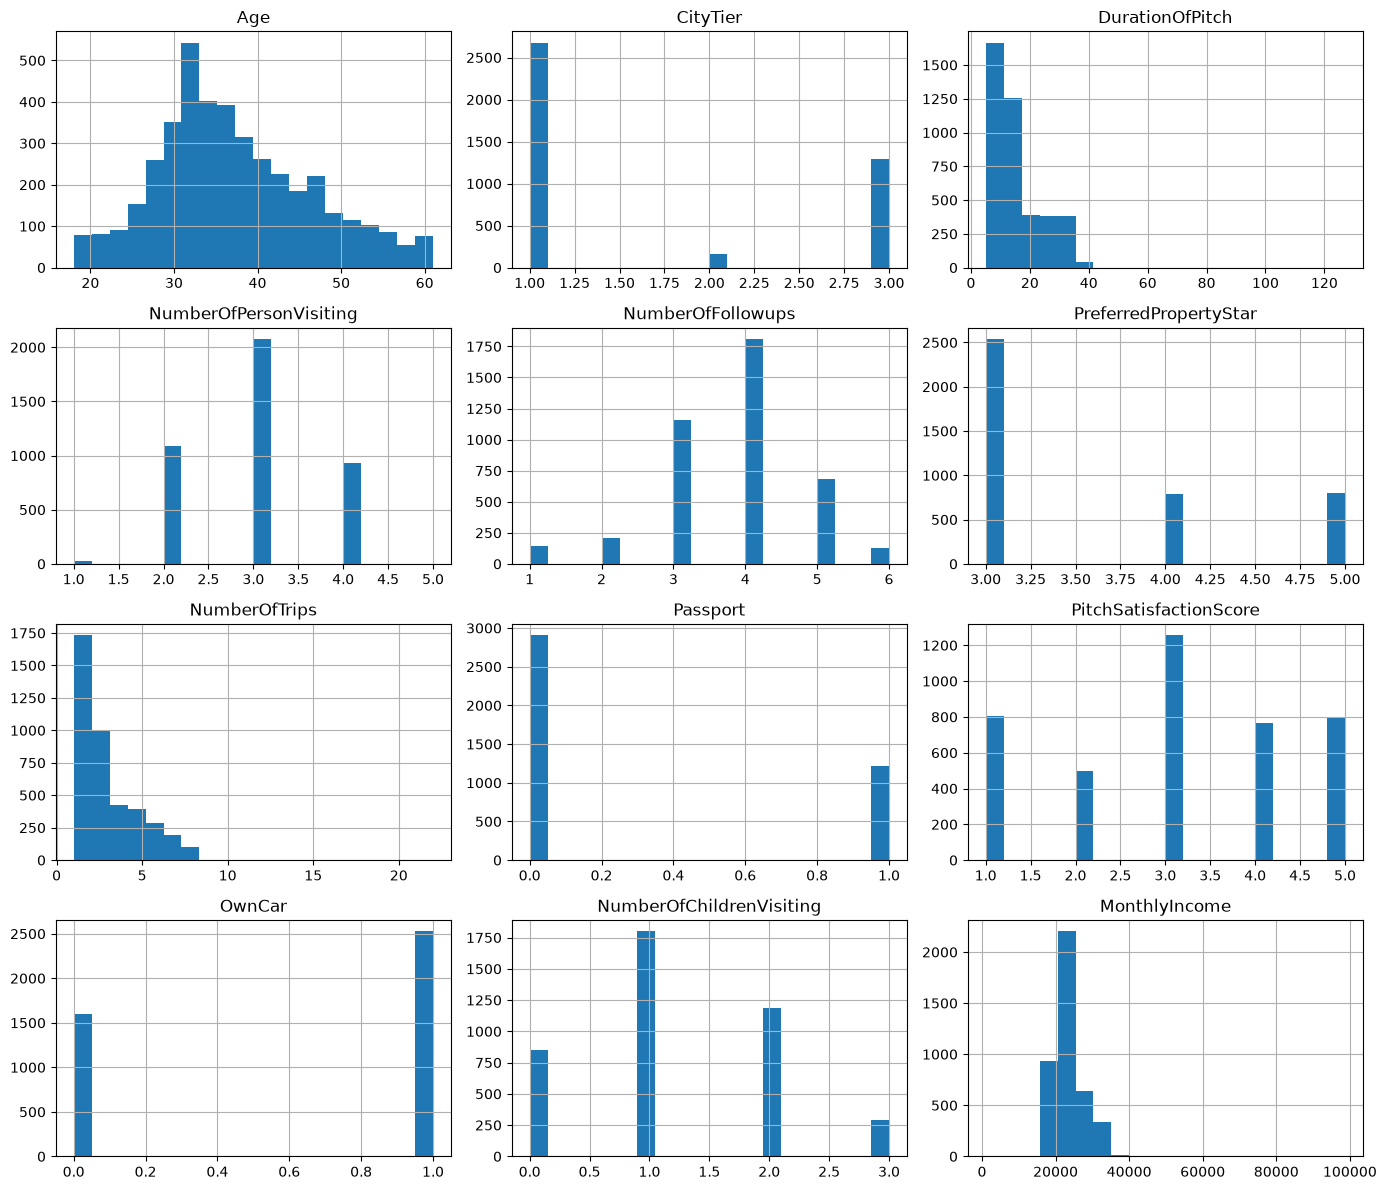

In [23]:
# Plot distributions of numerical features

import matplotlib.pyplot as plt

df[numerical_features].hist(
    figsize=(14, 12),
    bins=20
)

plt.tight_layout()
plt.show()

In [24]:
# Compare numerical features across package purchase groups

df.groupby("ProdTaken")[numerical_features].mean().T

ProdTaken,0,1
Age,37.927049,34.326223
CityTier,1.622336,1.834379
DurationOfPitch,15.247073,16.996236
NumberOfPersonVisiting,2.948064,2.954831
NumberOfFollowups,3.686881,3.969887
PreferredPropertyStar,3.539478,3.741531
NumberOfTrips,3.281297,3.353827
Passport,0.234764,0.548306
PitchSatisfactionScore,3.026118,3.205772
OwnCar,0.614230,0.603513


In [25]:
# Correlation of numerical features with the target

correlation_with_target = (
    df[numerical_features + ["ProdTaken"]]
    .corr()["ProdTaken"]
    .sort_values(ascending=False)
)

correlation_with_target

ProdTaken                   1.000000
Passport                    0.271293
NumberOfFollowups           0.110966
PreferredPropertyStar       0.100325
CityTier                    0.090921
DurationOfPitch             0.082220
PitchSatisfactionScore      0.052029
NumberOfTrips               0.015424
NumberOfChildrenVisiting    0.008491
NumberOfPersonVisiting      0.003716
OwnCar                     -0.008681
MonthlyIncome              -0.133581
Age                        -0.154934
Name: ProdTaken, dtype: float64

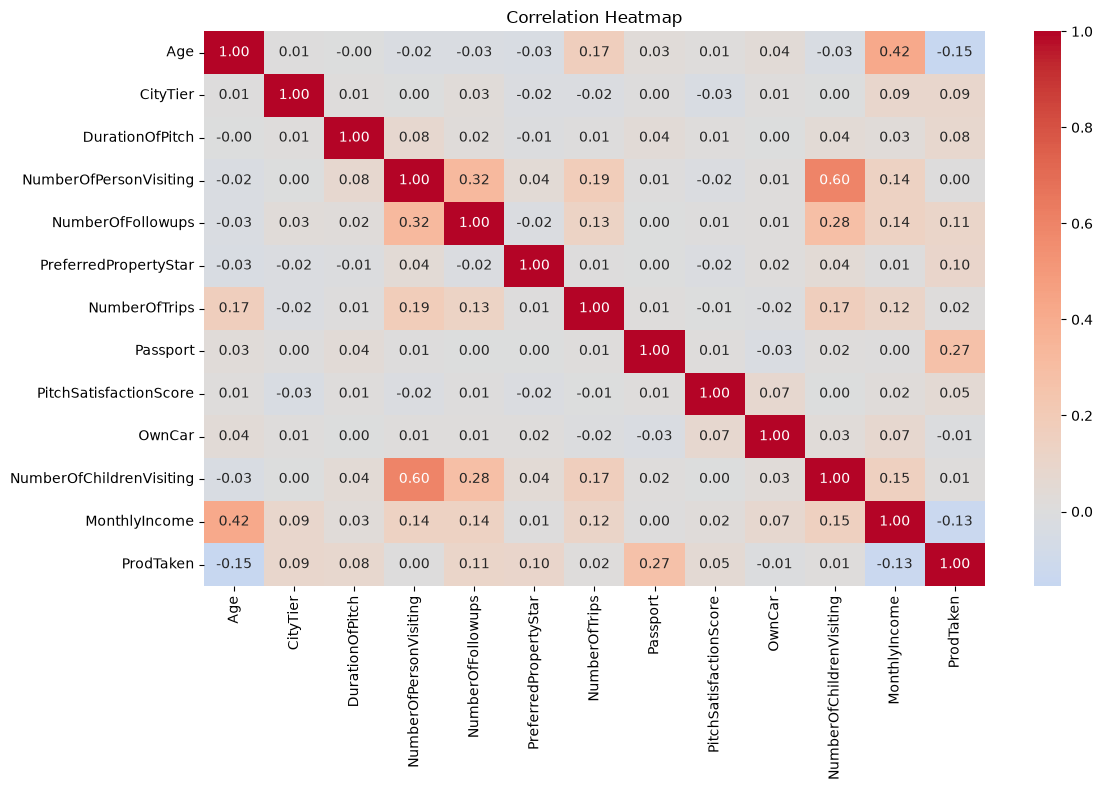

In [26]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_features + ["ProdTaken"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### EDA Summary

The exploratory analysis examined the target distribution, data completeness, duplicate records, categorical variables, and numerical variables. The target variable is imbalanced, with fewer customers purchasing the tourism package than not purchasing it. Numerical variables differ in scale and distribution, while categorical variables contain several distinct customer and product-related categories. Some categorical values also require standardization during the data-cleaning stage.

The next stage is data preparation, where unnecessary identifier columns will be removed, categorical inconsistencies will be addressed, the features and target will be separated, and the cleaned dataset will be divided into training and testing sets.

## Data Preparation

The data preparation stage involves cleaning the dataset, removing unnecessary identifier columns, standardizing inconsistent categorical values, separating the target variable, and preparing the data for model development.

In [27]:
# Create a copy of the original dataset for data preparation
df_clean = df.copy()

# Display the shape before cleaning
df_clean.shape

(4128, 21)

In [28]:
# Remove unnecessary identifier columns
df_clean = df_clean.drop(columns=["Unnamed: 0", "CustomerID"])

# Check the remaining columns
df_clean.columns.tolist()

['ProdTaken',
 'Age',
 'TypeofContact',
 'CityTier',
 'DurationOfPitch',
 'Occupation',
 'Gender',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'ProductPitched',
 'PreferredPropertyStar',
 'MaritalStatus',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'Designation',
 'MonthlyIncome']

In [29]:
# Standardize inconsistent gender labels
df_clean["Gender"] = df_clean["Gender"].replace({
    "Fe Male": "Female"
})

# Verify the corrected values
df_clean["Gender"].value_counts()

Gender
Male      2463
Female    1665
Name: count, dtype: int64

In [30]:
# Check for missing values after cleaning
df_clean.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [31]:
# Check for duplicate rows after cleaning
df_clean.duplicated().sum()

np.int64(117)

### Separating Features and Target

The target variable is `ProdTaken`, which indicates whether the customer purchased the Wellness Tourism Package. All remaining variables will be used as input features.

In [32]:
# Separate input features and target variable
X = df_clean.drop(columns=["ProdTaken"])
y = df_clean["ProdTaken"]

# Check their shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4128, 18)
Target shape: (4128,)


### Train-Test Split

The cleaned dataset is divided into training and testing sets. An 80:20 split is used, with 80% of the observations used for training and 20% reserved for testing.

Stratification is applied to preserve the proportion of the two target classes (`ProdTaken = 0` and `ProdTaken = 1`) in both datasets.

In [33]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# stratify=y preserves the target class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3302, 18)
X_test shape: (826, 18)
y_train shape: (3302,)
y_test shape: (826,)


In [34]:
# Compare target proportions before and after the split

print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Original target distribution:
ProdTaken
0    0.806928
1    0.193072
Name: proportion, dtype: float64

Training target distribution:
ProdTaken
0    0.806784
1    0.193216
Name: proportion, dtype: float64

Testing target distribution:
ProdTaken
0    0.807506
1    0.192494
Name: proportion, dtype: float64


### Saving Training and Testing Data

The training and testing datasets are saved as separate CSV files. These files will later be uploaded to the Hugging Face dataset repository and used for model development.

In [35]:
# Combine features and target for the training dataset
train_data = X_train.copy()
train_data["ProdTaken"] = y_train

# Combine features and target for the testing dataset
test_data = X_test.copy()
test_data["ProdTaken"] = y_test

# Save the datasets as CSV files
train_data.to_csv("train.csv", index=False)
test_data.to_csv("test.csv", index=False)

print("Training and testing datasets saved successfully.")

Training and testing datasets saved successfully.


In [36]:
# Verify the saved dataset shapes
print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (3302, 19)
Testing data shape: (826, 19)


### Uploading Train and Test Data to Hugging Face

The prepared training and testing datasets are uploaded to the Hugging Face dataset repository so that they can be accessed directly during model development and subsequent MLOps stages.

In [37]:
!pip install -U huggingface_hub

   ---------------------------------------- 0.0/842.9 kB ? eta -:--:--
   ------------------------ --------------- 524.3/842.9 kB 5.5 MB/s eta 0:00:01
   ----------------------------------- -- 786.4/842.9 kB 632.9 kB/s eta 0:00:01
   ---------------------------------------- 842.9/842.9 kB 424.6 kB/s  0:00:01
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   --------------- ------------------------ 1.6/4.0 MB 6.3 MB/s eta 0:00:01
   -------------------------------------- - 3.9/4.0 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 3.8 MB/s  0:00:01

   ---------------------------------------- 0/5 [hf-xet]
   ---------------------------------------- 0/5 [hf-xet]
   ---------------------------------------- 0/5 [hf-xet]
   ---------------------------------------- 0/5 [hf-xet]
   -------- ------------------------------- 1/5 [fsspec]
   -------- ------------------------------- 1/5 [fsspec]
   -------- ------------------------------- 1/5 [fssp


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from huggingface_hub import login

login()

In [40]:
from huggingface_hub import HfApi

# Create a Hugging Face API client
api = HfApi()

# Hugging Face dataset repository
repo_id = "rashmikportfolio/tourism-package-prediction"

print("Ready to upload files to:", repo_id)

Ready to upload files to: rashmikportfolio/tourism-package-prediction


In [41]:
# Upload the training dataset
api.upload_file(
    path_or_fileobj="data/train.csv",
    path_in_repo="train.csv",
    repo_id=repo_id,
    repo_type="dataset"
)

print("train.csv uploaded successfully.")

train.csv uploaded successfully.


In [42]:
# Upload the testing dataset
api.upload_file(
    path_or_fileobj="data/test.csv",
    path_in_repo="test.csv",
    repo_id=repo_id,
    repo_type="dataset"
)

print("test.csv uploaded successfully.")

test.csv uploaded successfully.


## Model Building and Experimentation Tracking

The prepared training and testing datasets are loaded directly from the Hugging Face dataset repository. The training data will be used for model development and experimentation, while the testing data will be reserved for final evaluation.

In [43]:
# Hugging Face URLs for the prepared datasets
train_url = "https://huggingface.co/datasets/rashmikportfolio/tourism-package-prediction/resolve/main/train.csv"
test_url = "https://huggingface.co/datasets/rashmikportfolio/tourism-package-prediction/resolve/main/test.csv"

# Load the datasets directly from Hugging Face
train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

# Check the dataset shapes
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (3302, 19)
Testing data shape: (826, 19)


### Separating Features and Target

The target variable `ProdTaken` is separated from the predictor variables in both the training and testing datasets.

In [44]:
# Separate features and target for the training data
X_train = train_df.drop(columns=["ProdTaken"])
y_train = train_df["ProdTaken"]

# Separate features and target for the testing data
X_test = test_df.drop(columns=["ProdTaken"])
y_test = test_df["ProdTaken"]

# Check the shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3302, 18)
y_train shape: (3302,)
X_test shape: (826, 18)
y_test shape: (826,)


### Identifying Numerical and Categorical Features

The predictor variables are divided into numerical and categorical features. Categorical variables will later be encoded using one-hot encoding, while numerical variables will be passed through without scaling because the tree-based models used in this project do not require feature scaling.

In [46]:
# Identify numerical and categorical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']

Categorical features:
['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


### Feature Preprocessing

Numerical features are passed through without scaling because the tree-based models used in this project do not require feature scaling. Categorical features are transformed using one-hot encoding so that they can be used by machine learning models.

A `ColumnTransformer` applies the appropriate preprocessing to each group of features.

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Applying the Preprocessing Pipeline

The preprocessing pipeline is fitted using the training data and then applied to both the training and testing data. The encoder is fitted only on the training data to prevent data leakage from the test set.

In [48]:
# Fit the preprocessing pipeline on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the fitted preprocessing pipeline to the test data
X_test_processed = preprocessor.transform(X_test)

# Check the resulting shapes
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (3302, 34)
Processed testing data shape: (826, 34)


### Baseline Model: Decision Tree

A Decision Tree classifier is used as the first baseline model. The baseline provides an initial performance benchmark before hyperparameter tuning and experimentation with other tree-based ensemble models.

In [49]:
from sklearn.tree import DecisionTreeClassifier

# Create the baseline Decision Tree model
baseline_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
baseline_model.fit(X_train_processed, y_train)

print("Baseline Decision Tree trained successfully.")

Baseline Decision Tree trained successfully.


In [50]:
# Generate predictions on the test data
y_pred = baseline_model.predict(X_test_processed)

# Generate predicted probabilities for the positive class
y_prob = baseline_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### Baseline Model Evaluation

The baseline Decision Tree is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Since the target variable is imbalanced, multiple evaluation metrics are considered rather than relying only on accuracy.

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display the results
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8971
Precision: 0.7342
Recall:    0.7296
F1-score:  0.7319
ROC-AUC:   0.8333


### Baseline Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each target class. It provides additional insight into the model's ability to identify customers who purchased and did not purchase the tourism package.

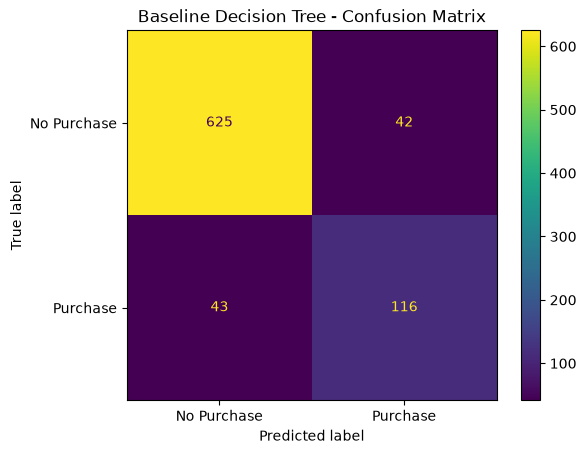

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
)

disp.plot()
plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()

### Decision Tree Hyperparameter Tuning

Hyperparameter tuning is performed using `GridSearchCV` to identify a suitable combination of Decision Tree parameters. Cross-validation is used on the training data so that the test set remains reserved for final evaluation.

In [53]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter combinations to test
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

# Create a Decision Tree for tuning
dt_model = DecisionTreeClassifier(random_state=42)

# Set up grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run hyperparameter tuning
grid_search.fit(X_train_processed, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(f"{grid_search.best_score_:.4f}")

Best parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best cross-validation F1-score:
0.6966


### Tuned Decision Tree Evaluation

The best Decision Tree identified through cross-validation is evaluated on the held-out test dataset using accuracy, precision, recall, F1-score, and ROC-AUC.

In [54]:
# Get the best tuned Decision Tree
tuned_dt = grid_search.best_estimator_

# Generate predictions on the test data
tuned_y_pred = tuned_dt.predict(X_test_processed)

# Generate predicted probabilities for ROC-AUC
tuned_y_prob = tuned_dt.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
tuned_accuracy = accuracy_score(y_test, tuned_y_pred)
tuned_precision = precision_score(y_test, tuned_y_pred)
tuned_recall = recall_score(y_test, tuned_y_pred)
tuned_f1 = f1_score(y_test, tuned_y_pred)
tuned_roc_auc = roc_auc_score(y_test, tuned_y_prob)

# Display results
print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1-score:  {tuned_f1:.4f}")
print(f"ROC-AUC:   {tuned_roc_auc:.4f}")

Accuracy:  0.8971
Precision: 0.7342
Recall:    0.7296
F1-score:  0.7319
ROC-AUC:   0.8333


### Experimentation Tracking with MLflow

MLflow is used to track machine learning experiments, including model parameters and evaluation metrics. This provides a reproducible record of the models tested during experimentation.

In [56]:
import mlflow

# Create an MLflow experiment
mlflow.set_experiment("Tourism Package Prediction")

print("MLflow experiment is ready.")

2026/09/23 09:59:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/23 09:59:09 INFO mlflow.store.db.utils: Updating database tables
2026/09/23 09:59:15 INFO mlflow.tracking.fluent: Experiment with name 'Tourism Package Prediction' does not exist. Creating a new experiment.


MLflow experiment is ready.


In [57]:
# Track the tuned Decision Tree experiment
with mlflow.start_run(run_name="Tuned Decision Tree"):

    # Log model parameters
    mlflow.log_params(grid_search.best_params_)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", tuned_accuracy)
    mlflow.log_metric("precision", tuned_precision)
    mlflow.log_metric("recall", tuned_recall)
    mlflow.log_metric("f1_score", tuned_f1)
    mlflow.log_metric("roc_auc", tuned_roc_auc)

print("Tuned Decision Tree experiment logged successfully.")

2026/09/23 09:59:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/09/23 09:59:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

Tuned Decision Tree experiment logged successfully.


### Random Forest Experiment

A Random Forest classifier is evaluated as an ensemble model. Random Forest combines multiple decision trees and aggregates their predictions. Hyperparameter tuning is performed using cross-validation, and the resulting experiment is tracked using MLflow.

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Define the hyperparameters to tune
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Set up 5-fold cross-validation
rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run the tuning process
rf_grid_search.fit(X_train_processed, y_train)

print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(f"{rf_grid_search.best_score_:.4f}")

Best Random Forest parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation F1-score:
0.6887


In [59]:
# Get the best Random Forest model
tuned_rf = rf_grid_search.best_estimator_

# Generate predictions on the test data
rf_y_pred = tuned_rf.predict(X_test_processed)

# Generate predicted probabilities for ROC-AUC
rf_y_prob = tuned_rf.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_prob)

# Display results
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  0.9153
Precision: 0.9320
Recall:    0.6038
F1-score:  0.7328
ROC-AUC:   0.9671


In [60]:
# Track the tuned Random Forest experiment
with mlflow.start_run(run_name="Tuned Random Forest"):

    # Log the best model parameters
    mlflow.log_params(rf_grid_search.best_params_)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1_score", rf_f1)
    mlflow.log_metric("roc_auc", rf_roc_auc)

print("Tuned Random Forest experiment logged successfully.")

Tuned Random Forest experiment logged successfully.


### AdaBoost Experiment

AdaBoost is an ensemble learning method that combines multiple weak learners sequentially. Each new learner focuses more on observations that were incorrectly classified by previous learners. Hyperparameter tuning is performed using cross-validation, and the experiment is tracked using MLflow.

In [61]:
from sklearn.ensemble import AdaBoostClassifier

# Create the AdaBoost model
ada_model = AdaBoostClassifier(
    random_state=42
)

# Define the hyperparameters to tune
ada_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}

# Set up 5-fold cross-validation
ada_grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=ada_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run hyperparameter tuning
ada_grid_search.fit(X_train_processed, y_train)

print("Best AdaBoost parameters:")
print(ada_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(f"{ada_grid_search.best_score_:.4f}")

Best AdaBoost parameters:
{'learning_rate': 1.0, 'n_estimators': 100}

Best cross-validation F1-score:
0.4199


In [62]:
# Get the best AdaBoost model
tuned_ada = ada_grid_search.best_estimator_

# Generate predictions on the test data
ada_y_pred = tuned_ada.predict(X_test_processed)

# Generate predicted probabilities for ROC-AUC
ada_y_prob = tuned_ada.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
ada_accuracy = accuracy_score(y_test, ada_y_pred)
ada_precision = precision_score(y_test, ada_y_pred)
ada_recall = recall_score(y_test, ada_y_pred)
ada_f1 = f1_score(y_test, ada_y_pred)
ada_roc_auc = roc_auc_score(y_test, ada_y_prob)

# Display results
print(f"Accuracy:  {ada_accuracy:.4f}")
print(f"Precision: {ada_precision:.4f}")
print(f"Recall:    {ada_recall:.4f}")
print(f"F1-score:  {ada_f1:.4f}")
print(f"ROC-AUC:   {ada_roc_auc:.4f}")

Accuracy:  0.8462
Precision: 0.7424
Recall:    0.3082
F1-score:  0.4356
ROC-AUC:   0.8263


In [63]:
# Track the tuned AdaBoost experiment
with mlflow.start_run(run_name="Tuned AdaBoost"):

    # Log the best model parameters
    mlflow.log_params(ada_grid_search.best_params_)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", ada_accuracy)
    mlflow.log_metric("precision", ada_precision)
    mlflow.log_metric("recall", ada_recall)
    mlflow.log_metric("f1_score", ada_f1)
    mlflow.log_metric("roc_auc", ada_roc_auc)

print("Tuned AdaBoost experiment logged successfully.")

Tuned AdaBoost experiment logged successfully.


### Gradient Boosting Experiment

Gradient Boosting is an ensemble learning method that builds trees sequentially, with each new tree attempting to correct errors made by the previous trees. Hyperparameter tuning is performed using cross-validation, and the experiment is tracked using MLflow.

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

# Create the Gradient Boosting model
gb_model = GradientBoostingClassifier(
    random_state=42
)

# Define the hyperparameters to tune
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5]
}

# Set up 5-fold cross-validation
gb_grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run hyperparameter tuning
gb_grid_search.fit(X_train_processed, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(f"{gb_grid_search.best_score_:.4f}")

Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Best cross-validation F1-score:
0.7489


In [65]:
# Get the best Gradient Boosting model
tuned_gb = gb_grid_search.best_estimator_

# Generate predictions on the test data
gb_y_pred = tuned_gb.predict(X_test_processed)

# Generate predicted probabilities for ROC-AUC
gb_y_prob = tuned_gb.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
gb_accuracy = accuracy_score(y_test, gb_y_pred)
gb_precision = precision_score(y_test, gb_y_pred)
gb_recall = recall_score(y_test, gb_y_pred)
gb_f1 = f1_score(y_test, gb_y_pred)
gb_roc_auc = roc_auc_score(y_test, gb_y_prob)

# Display results
print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"F1-score:  {gb_f1:.4f}")
print(f"ROC-AUC:   {gb_roc_auc:.4f}")

Accuracy:  0.9274
Precision: 0.9160
Recall:    0.6855
F1-score:  0.7842
ROC-AUC:   0.9536


In [66]:
# Track the tuned Gradient Boosting experiment
with mlflow.start_run(run_name="Tuned Gradient Boosting"):

    # Log the best model parameters
    mlflow.log_params(gb_grid_search.best_params_)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", gb_accuracy)
    mlflow.log_metric("precision", gb_precision)
    mlflow.log_metric("recall", gb_recall)
    mlflow.log_metric("f1_score", gb_f1)
    mlflow.log_metric("roc_auc", gb_roc_auc)

print("Tuned Gradient Boosting experiment logged successfully.")

Tuned Gradient Boosting experiment logged successfully.


In [68]:
from xgboost import XGBClassifier

# Create the XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Define the hyperparameters to tune
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

# Set up 5-fold cross-validation
xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run hyperparameter tuning
xgb_grid_search.fit(X_train_processed, y_train)

print("Best XGBoost parameters:")
print(xgb_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(f"{xgb_grid_search.best_score_:.4f}")

Best XGBoost parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Best cross-validation F1-score:
0.7198


In [69]:
# Get the best XGBoost model
tuned_xgb = xgb_grid_search.best_estimator_

# Generate predictions on the test data
xgb_y_pred = tuned_xgb.predict(X_test_processed)

# Generate predicted probabilities for ROC-AUC
xgb_y_prob = tuned_xgb.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_prob)

# Display results
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")

Accuracy:  0.9104
Precision: 0.8899
Recall:    0.6101
F1-score:  0.7239
ROC-AUC:   0.9468


## Bagging Classifier Experiment

A Bagging Classifier is evaluated as an additional ensemble model. Bagging trains multiple base estimators on different samples of the training data and combines their predictions.

In [71]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create the base Bagging model
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

# Define the hyperparameters to tune
bagging_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_samples": [0.7, 1.0],
    "max_features": [0.7, 1.0]
}

# Set up 5-fold cross-validation
bagging_grid_search = GridSearchCV(
    estimator=bagging_model,
    param_grid=bagging_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run hyperparameter tuning
bagging_grid_search.fit(X_train_processed, y_train)

print("Best Bagging parameters:")
print(bagging_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(f"{bagging_grid_search.best_score_:.4f}")

Best Bagging parameters:
{'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 200}

Best cross-validation F1-score:
0.7596


In [72]:
# Get the best Bagging model
tuned_bagging = bagging_grid_search.best_estimator_

# Generate predictions on the test data
bagging_y_pred = tuned_bagging.predict(X_test_processed)

# Generate predicted probabilities for ROC-AUC
bagging_y_prob = tuned_bagging.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
bagging_accuracy = accuracy_score(y_test, bagging_y_pred)
bagging_precision = precision_score(y_test, bagging_y_pred)
bagging_recall = recall_score(y_test, bagging_y_pred)
bagging_f1 = f1_score(y_test, bagging_y_pred)
bagging_roc_auc = roc_auc_score(y_test, bagging_y_prob)

# Display results
print(f"Accuracy: {bagging_accuracy:.4f}")
print(f"Precision: {bagging_precision:.4f}")
print(f"Recall: {bagging_recall:.4f}")
print(f"F1-score: {bagging_f1:.4f}")
print(f"ROC-AUC: {bagging_roc_auc:.4f}")

Accuracy: 0.9262
Precision: 0.9083
Recall: 0.6855
F1-score: 0.7814
ROC-AUC: 0.9754


## Model Comparison

The tuned models are compared using accuracy, precision, recall, F1-score, and ROC-AUC. Since the target variable is imbalanced, F1-score and ROC-AUC are considered alongside accuracy.

In [73]:
# Create an updated comparison table including Bagging

model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bagging",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        tuned_accuracy,
        bagging_accuracy,
        rf_accuracy,
        ada_accuracy,
        gb_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        tuned_precision,
        bagging_precision,
        rf_precision,
        ada_precision,
        gb_precision,
        xgb_precision
    ],
    "Recall": [
        tuned_recall,
        bagging_recall,
        rf_recall,
        ada_recall,
        gb_recall,
        xgb_recall
    ],
    "F1-Score": [
        tuned_f1,
        bagging_f1,
        rf_f1,
        ada_f1,
        gb_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        tuned_roc_auc,
        bagging_roc_auc,
        rf_roc_auc,
        ada_roc_auc,
        gb_roc_auc,
        xgb_roc_auc
    ]
})

# Display the updated comparison table
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.8971,0.7342,0.7296,0.7319,0.8333
1,Bagging,0.9262,0.9083,0.6855,0.7814,0.9754
2,Random Forest,0.9153,0.9320,0.6038,0.7328,0.9671
3,AdaBoost,0.8462,0.7424,0.3082,0.4356,0.8263
4,Gradient Boosting,0.9274,0.9160,0.6855,0.7842,0.9536
5,XGBoost,0.9104,0.8899,0.6101,0.7239,0.9468


## Loading Training and Testing Data from Hugging Face

The training and testing datasets uploaded during data preparation are loaded directly from the Hugging Face dataset repository for model development.

In [74]:
# Hugging Face URLs for the training and testing datasets

train_url = "https://huggingface.co/datasets/rashmikportfolio/tourism-package-prediction/resolve/main/train.csv"
test_url = "https://huggingface.co/datasets/rashmikportfolio/tourism-package-prediction/resolve/main/test.csv"

# Load the datasets directly from Hugging Face
train_data_hf = pd.read_csv(train_url)
test_data_hf = pd.read_csv(test_url)

# Display the shapes
print("Training data shape:", train_data_hf.shape)
print("Testing data shape:", test_data_hf.shape)

Training data shape: (3302, 19)
Testing data shape: (826, 19)


In [75]:
# Separate features and target from the Hugging Face datasets

X_train_hf = train_data_hf.drop(columns=["ProdTaken"])
y_train_hf = train_data_hf["ProdTaken"]

X_test_hf = test_data_hf.drop(columns=["ProdTaken"])
y_test_hf = test_data_hf["ProdTaken"]

print("Training features shape:", X_train_hf.shape)
print("Testing features shape:", X_test_hf.shape)

Training features shape: (3302, 18)
Testing features shape: (826, 18)


In [76]:
# Verify that the Hugging Face datasets match the datasets used earlier

print("Training data matches:", train_data_hf.equals(train_data))
print("Testing data matches:", test_data_hf.equals(test_data))

Training data matches: False
Testing data matches: False


In [77]:
# Check whether the datasets contain the same values and columns

print("Train columns match:",
      list(train_data_hf.columns) == list(train_data.columns))

print("Test columns match:",
      list(test_data_hf.columns) == list(test_data.columns))

print("\nTrain shapes:")
print("Original:", train_data.shape)
print("HF:", train_data_hf.shape)

print("\nTest shapes:")
print("Original:", test_data.shape)
print("HF:", test_data_hf.shape)

print("\nTrain data types:")
print("Original:")
print(train_data.dtypes)
print("\nHF:")
print(train_data_hf.dtypes)

Train columns match: True
Test columns match: True

Train shapes:
Original: (3302, 19)
HF: (3302, 19)

Test shapes:
Original: (826, 19)
HF: (826, 19)

Train data types:
Original:
Age                         float64
TypeofContact                   str
CityTier                      int64
DurationOfPitch             float64
Occupation                      str
Gender                          str
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched                  str
PreferredPropertyStar       float64
MaritalStatus                   str
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                     str
MonthlyIncome               float64
ProdTaken                     int64
dtype: object

HF:
Age                         float64
TypeofContact                   str
CityTier                      int64
DurationOf

In [78]:
# Check whether the original and Hugging Face data
# contain the same values after resetting the index

train_check = train_data.reset_index(drop=True)
train_hf_check = train_data_hf.reset_index(drop=True)

test_check = test_data.reset_index(drop=True)
test_hf_check = test_data_hf.reset_index(drop=True)

print("Train values match:",
      train_check.equals(train_hf_check))

print("Test values match:",
      test_check.equals(test_hf_check))

# Check the number of individual cells that differ
print("\nTrain differing cells:",
      (train_check != train_hf_check).sum().sum())

print("Test differing cells:",
      (test_check != test_hf_check).sum().sum())

Train values match: True
Test values match: True

Train differing cells: 0
Test differing cells: 0


## Preparing Training and Testing Data from Hugging Face

The training and testing datasets are loaded from Hugging Face and separated into predictor variables and the target variable. These Hugging Face datasets will be used for the subsequent model development stages.

In [79]:
# Separate predictor variables and target variable
# using the datasets loaded from Hugging Face

X_train_hf = train_data_hf.drop(columns=["ProdTaken"])
y_train_hf = train_data_hf["ProdTaken"]

X_test_hf = test_data_hf.drop(columns=["ProdTaken"])
y_test_hf = test_data_hf["ProdTaken"]

# Display the shapes
print("X_train shape:", X_train_hf.shape)
print("y_train shape:", y_train_hf.shape)
print("X_test shape:", X_test_hf.shape)
print("y_test shape:", y_test_hf.shape)

X_train shape: (3302, 18)
y_train shape: (3302,)
X_test shape: (826, 18)
y_test shape: (826,)


In [80]:
# Identify numerical and categorical features
# from the Hugging Face training data

numerical_features_hf = X_train_hf.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_hf = X_train_hf.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features_hf)

print("\nCategorical features:")
print(categorical_features_hf)

Numerical features:
['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']

Categorical features:
['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create preprocessing pipeline using the Hugging Face data

preprocessor_hf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features_hf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_hf)
    ]
)

# Fit preprocessing only on the training data
X_train_processed_hf = preprocessor_hf.fit_transform(X_train_hf)

# Apply the same preprocessing to the test data
X_test_processed_hf = preprocessor_hf.transform(X_test_hf)

print("Processed HF training data shape:", X_train_processed_hf.shape)
print("Processed HF testing data shape:", X_test_processed_hf.shape)

Processed HF training data shape: (3302, 34)
Processed HF testing data shape: (826, 34)


## Final Model Selection

The tuned models are compared using F1-score and ROC-AUC along with accuracy, precision, and recall. The model selected for deployment will be based on its overall evaluation performance, with particular attention to F1-score and ROC-AUC because the target variable is imbalanced.

In [82]:
# Create a copy of the model comparison table
final_model_comparison = model_comparison.copy()

# Display the complete comparison
final_model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.8971,0.7342,0.7296,0.7319,0.8333
1,Bagging,0.9262,0.9083,0.6855,0.7814,0.9754
2,Random Forest,0.9153,0.9320,0.6038,0.7328,0.9671
3,AdaBoost,0.8462,0.7424,0.3082,0.4356,0.8263
4,Gradient Boosting,0.9274,0.9160,0.6855,0.7842,0.9536
5,XGBoost,0.9104,0.8899,0.6101,0.7239,0.9468


In [83]:
# Identify the model with the highest F1-score
best_model_name = final_model_comparison.loc[
    final_model_comparison["F1-Score"].idxmax(),
    "Model"
]

print("Selected model based on F1-score:", best_model_name)

Selected model based on F1-score: Gradient Boosting


## Final Model Training Using Hugging Face Data

The Gradient Boosting model was selected based on the model comparison. The final model is now trained using the training data loaded from Hugging Face and the tuned hyperparameters identified during experimentation.

In [84]:
from sklearn.ensemble import GradientBoostingClassifier

# Create the final Gradient Boosting model
final_model = GradientBoostingClassifier(
    **gb_grid_search.best_params_
)

# Train the final model using the Hugging Face training data
final_model.fit(X_train_processed_hf, y_train_hf)

print("Final Gradient Boosting model trained successfully.")

Final Gradient Boosting model trained successfully.


In [85]:
# Generate predictions using the final model
final_y_pred = final_model.predict(X_test_processed_hf)

# Generate probabilities for ROC-AUC
final_y_prob = final_model.predict_proba(X_test_processed_hf)[:, 1]

# Calculate evaluation metrics
final_accuracy = accuracy_score(y_test_hf, final_y_pred)
final_precision = precision_score(y_test_hf, final_y_pred)
final_recall = recall_score(y_test_hf, final_y_pred)
final_f1 = f1_score(y_test_hf, final_y_pred)
final_roc_auc = roc_auc_score(y_test_hf, final_y_prob)

print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")

Accuracy:  0.9286
Precision: 0.9167
Recall:    0.6918
F1-score:  0.7885
ROC-AUC:   0.9538


## Final Model Pipeline

The final preprocessing steps and Gradient Boosting model are combined into a single pipeline. This ensures that the same preprocessing used during training is automatically applied when new customer data is provided during deployment.

In [86]:
from sklearn.pipeline import Pipeline

# Create the final end-to-end pipeline
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_hf),
        ("model", GradientBoostingClassifier(
            **gb_grid_search.best_params_
        ))
    ]
)

# Train the complete pipeline on the Hugging Face training data
final_pipeline.fit(X_train_hf, y_train_hf)

print("Final end-to-end pipeline trained successfully.")

Final end-to-end pipeline trained successfully.


In [87]:
# Test the complete pipeline using the raw Hugging Face test data
pipeline_predictions = final_pipeline.predict(X_test_hf)
pipeline_probabilities = final_pipeline.predict_proba(X_test_hf)[:, 1]

pipeline_f1 = f1_score(y_test_hf, pipeline_predictions)
pipeline_roc_auc = roc_auc_score(y_test_hf, pipeline_probabilities)

print(f"Pipeline F1-score: {pipeline_f1:.4f}")
print(f"Pipeline ROC-AUC: {pipeline_roc_auc:.4f}")

Pipeline F1-score: 0.7842
Pipeline ROC-AUC: 0.9541


## Saving the Final Model Pipeline

The complete preprocessing and model pipeline is saved as a single artifact. This artifact will later be registered on Hugging Face and used during deployment.

In [89]:
import joblib
import os

# Create a folder for the final model
os.makedirs("model", exist_ok=True)

# Path where the final pipeline will be saved
model_path = "model/tourism_package_pipeline.joblib"

# Save the complete preprocessing + model pipeline
joblib.dump(final_pipeline, model_path)

print(f"Final model pipeline saved to: {model_path}")

Final model pipeline saved to: model/tourism_package_pipeline.joblib


In [90]:
# Verify that the model file was created
print("Model file exists:", os.path.exists(model_path))

print(
    "Model file size:",
    round(os.path.getsize(model_path) / 1024, 2),
    "KB"
)

Model file exists: True
Model file size: 856.65 KB


In [91]:
!pip install -q huggingface_hub


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
from huggingface_hub import login

# Log in to your Hugging Face account
login()

In [93]:
from huggingface_hub import HfApi

# Create Hugging Face Model Hub repository
api = HfApi()

model_repo = "rashmikportfolio/tourism-package-prediction-model"

api.create_repo(
    repo_id=model_repo,
    repo_type="model",
    exist_ok=True
)

print("Hugging Face model repository created successfully.")
print("Repository:", model_repo)

Hugging Face model repository created successfully.
Repository: rashmikportfolio/tourism-package-prediction-model


In [94]:
from huggingface_hub import HfApi

# Create the Hugging Face API connection
api = HfApi()

# Upload the saved model pipeline
api.upload_file(
    path_or_fileobj="model/tourism_package_pipeline.joblib",
    path_in_repo="tourism_package_pipeline.joblib",
    repo_id="rashmikportfolio/tourism-package-prediction-model",
    repo_type="model"
)

print("Final model uploaded successfully to Hugging Face Model Hub.")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Final model uploaded successfully to Hugging Face Model Hub.


In [95]:
from huggingface_hub import list_repo_files

# Check the files available in the model repository
files = list_repo_files(
    repo_id="rashmikportfolio/tourism-package-prediction-model",
    repo_type="model"
)

print("Files in Hugging Face Model Hub:")
for file in files:
    print("-", file)

Files in Hugging Face Model Hub:
- .gitattributes
- tourism_package_pipeline.joblib


## Deployment Preparation

The trained model pipeline is registered on Hugging Face Model Hub. The deployment application will load this pipeline directly from Hugging Face and use customer inputs to generate a wellness tourism package prediction.

In [96]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib
from huggingface_hub import hf_hub_download

# Hugging Face Model Hub repository
MODEL_REPO = "rashmikportfolio/tourism-package-prediction-model"

# Download the trained model pipeline from Hugging Face
model_path = hf_hub_download(
    repo_id=MODEL_REPO,
    filename="tourism_package_pipeline.joblib"
)

# Load the trained pipeline
model = joblib.load(model_path)

# Streamlit application
st.title("Tourism Package Prediction")

st.write(
    "Enter customer information to predict whether the customer "
    "will purchase the Wellness Tourism Package."
)

# Customer inputs
age = st.number_input("Age", min_value=18, max_value=100, value=30)
type_of_contact = st.selectbox(
    "Type of Contact",
    ["Self Enquiry", "Company Invited"]
)
city_tier = st.selectbox("City Tier", [1, 2, 3])
duration_of_pitch = st.number_input(
    "Duration of Pitch",
    min_value=0.0,
    value=10.0
)
occupation = st.selectbox(
    "Occupation",
    ["Salaried", "Small Business", "Large Business", "Free Lancer"]
)
gender = st.selectbox("Gender", ["Male", "Female"])
number_of_person_visiting = st.number_input(
    "Number of Persons Visiting",
    min_value=1,
    value=2
)
number_of_followups = st.number_input(
    "Number of Followups",
    min_value=0.0,
    value=3.0
)
product_pitched = st.selectbox(
    "Product Pitched",
    ["Basic", "Deluxe", "Standard", "Super Deluxe", "King"]
)
preferred_property_star = st.selectbox(
    "Preferred Property Star",
    [3.0, 4.0, 5.0]
)
marital_status = st.selectbox(
    "Marital Status",
    ["Married", "Divorced", "Unmarried", "Single"]
)
number_of_trips = st.number_input(
    "Number of Trips",
    min_value=0.0,
    value=3.0
)
passport = st.selectbox("Passport", [0, 1])
pitch_satisfaction_score = st.selectbox(
    "Pitch Satisfaction Score",
    [1, 2, 3, 4, 5]
)
own_car = st.selectbox("Own Car", [0, 1])
number_of_children_visiting = st.number_input(
    "Number of Children Visiting",
    min_value=0.0,
    value=1.0
)
designation = st.selectbox(
    "Designation",
    ["Executive", "Manager", "Senior Manager", "AVP", "VP"]
)
monthly_income = st.number_input(
    "Monthly Income",
    min_value=0.0,
    value=20000.0
)

# Create input dataframe
input_data = pd.DataFrame([{
    "Age": age,
    "TypeofContact": type_of_contact,
    "CityTier": city_tier,
    "DurationOfPitch": duration_of_pitch,
    "Occupation": occupation,
    "Gender": gender,
    "NumberOfPersonVisiting": number_of_person_visiting,
    "NumberOfFollowups": number_of_followups,
    "ProductPitched": product_pitched,
    "PreferredPropertyStar": preferred_property_star,
    "MaritalStatus": marital_status,
    "NumberOfTrips": number_of_trips,
    "Passport": passport,
    "PitchSatisfactionScore": pitch_satisfaction_score,
    "OwnCar": own_car,
    "NumberOfChildrenVisiting": number_of_children_visiting,
    "Designation": designation,
    "MonthlyIncome": monthly_income
}])

# Make prediction
if st.button("Predict"):

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        st.success(
            "Prediction: Customer is likely to purchase the Wellness Tourism Package."
        )
    else:
        st.info(
            "Prediction: Customer is unlikely to purchase the Wellness Tourism Package."
        )
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [97]:
requirements = """streamlit
pandas
scikit-learn
joblib
huggingface_hub
"""

with open("requirements.txt", "w", encoding="utf-8") as file:
    file.write(requirements)

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [98]:
dockerfile = """FROM python:3.11-slim

# Set the working directory
WORKDIR /app

# Copy dependency file
COPY requirements.txt .

# Install dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the Streamlit application
COPY app.py .

# Hugging Face Spaces uses port 7860
EXPOSE 7860

# Start the Streamlit application
CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0", "--server.port=7860"]
"""

with open("Dockerfile", "w", encoding="utf-8") as file:
    file.write(dockerfile)

print("Dockerfile created successfully.")

Dockerfile created successfully.


In [99]:
import os

deployment_files = [
    "app.py",
    "requirements.txt",
    "Dockerfile"
]

print("Deployment files:")
for file in deployment_files:
    print(file, "->", os.path.exists(file))

Deployment files:
app.py -> True
requirements.txt -> True
Dockerfile -> True


# Output Evaluation

## Project Links

1. **GitHub Repository:**  
   [View GitHub Repository](https://github.com/rashmikportfolio/tourism-package-prediction)

2. **Live Streamlit Application:**  
   [Open Streamlit Application](https://tourism-package-prediction-tsmmrumndsy4kdlyf8f5dd.streamlit.app)

3. **Hugging Face Dataset:**  
   [View Hugging Face Dataset](https://huggingface.co/datasets/rashmikportfolio/tourism-package-prediction)

4. **Hugging Face Model:**  
   [View Hugging Face Model](https://huggingface.co/rashmikportfolio/tourism-package-prediction-model)


## Screenshots / Deployment Evidence


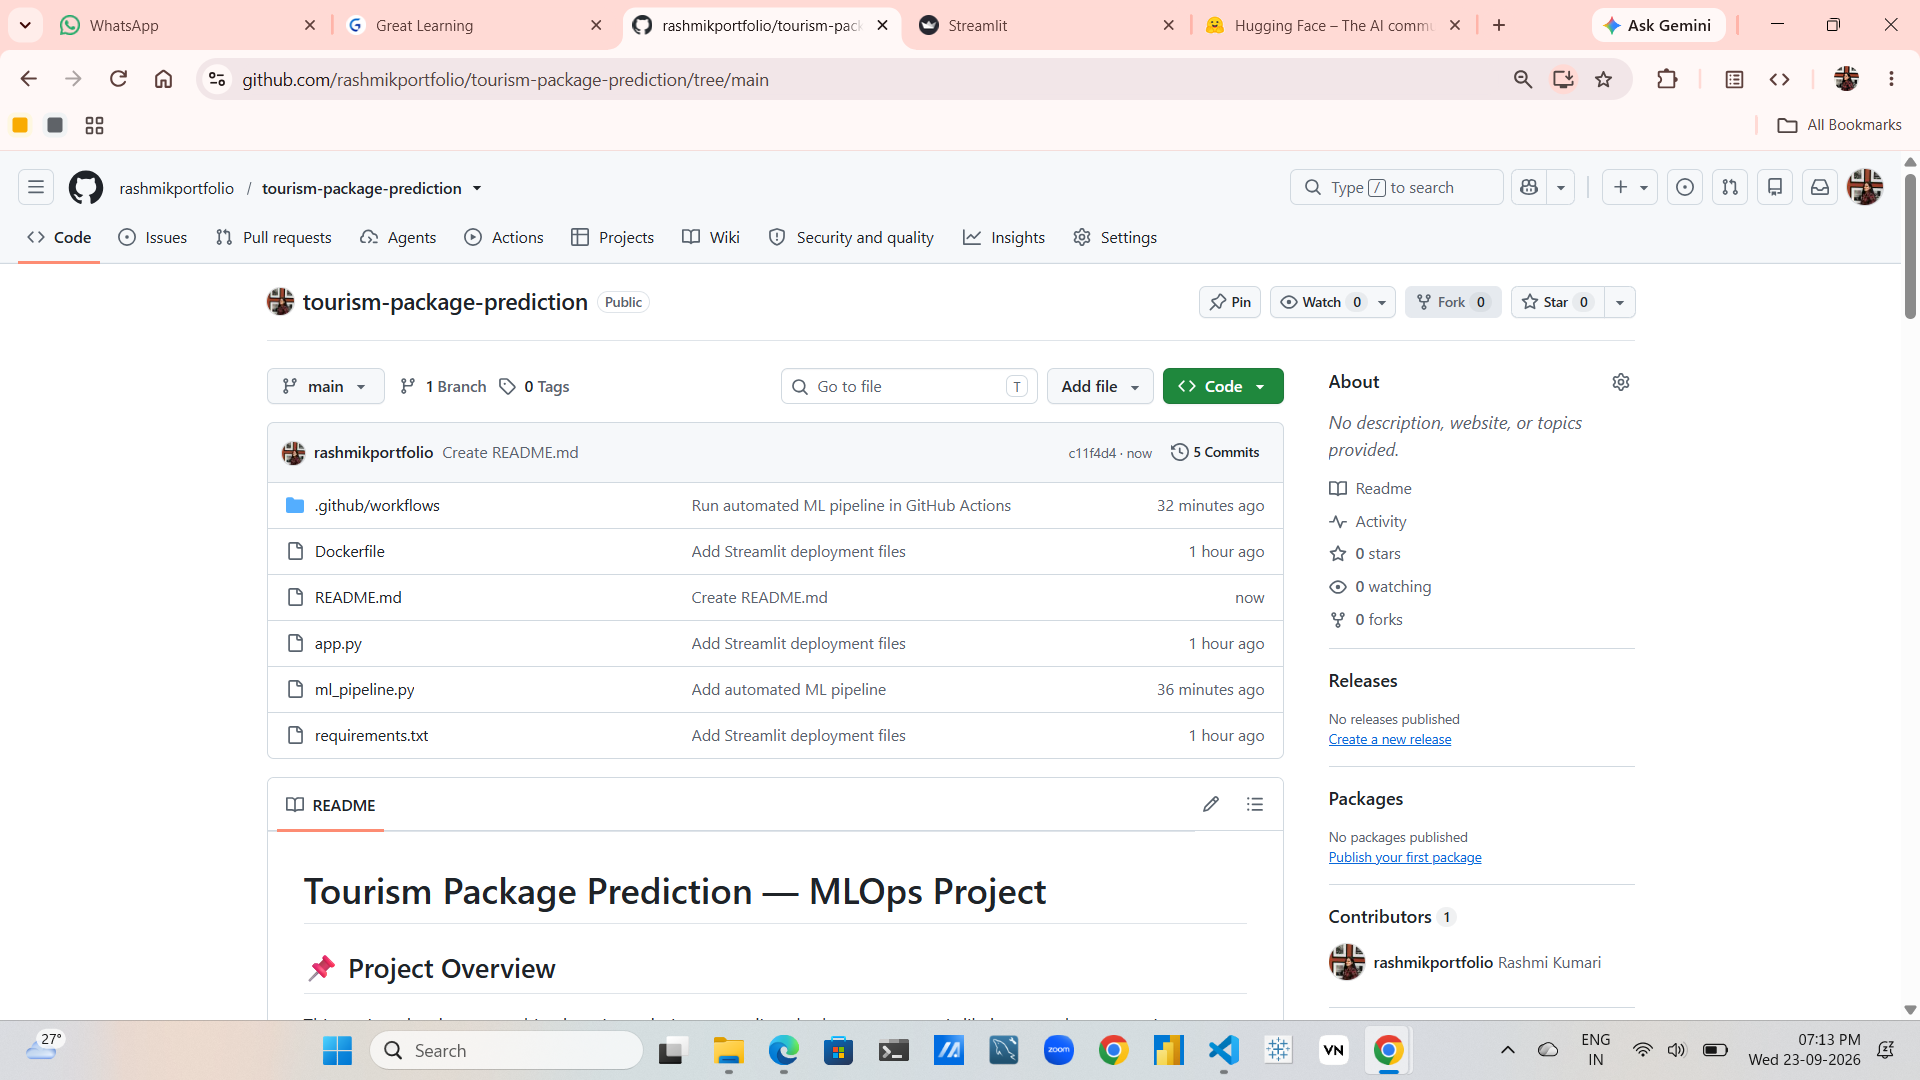


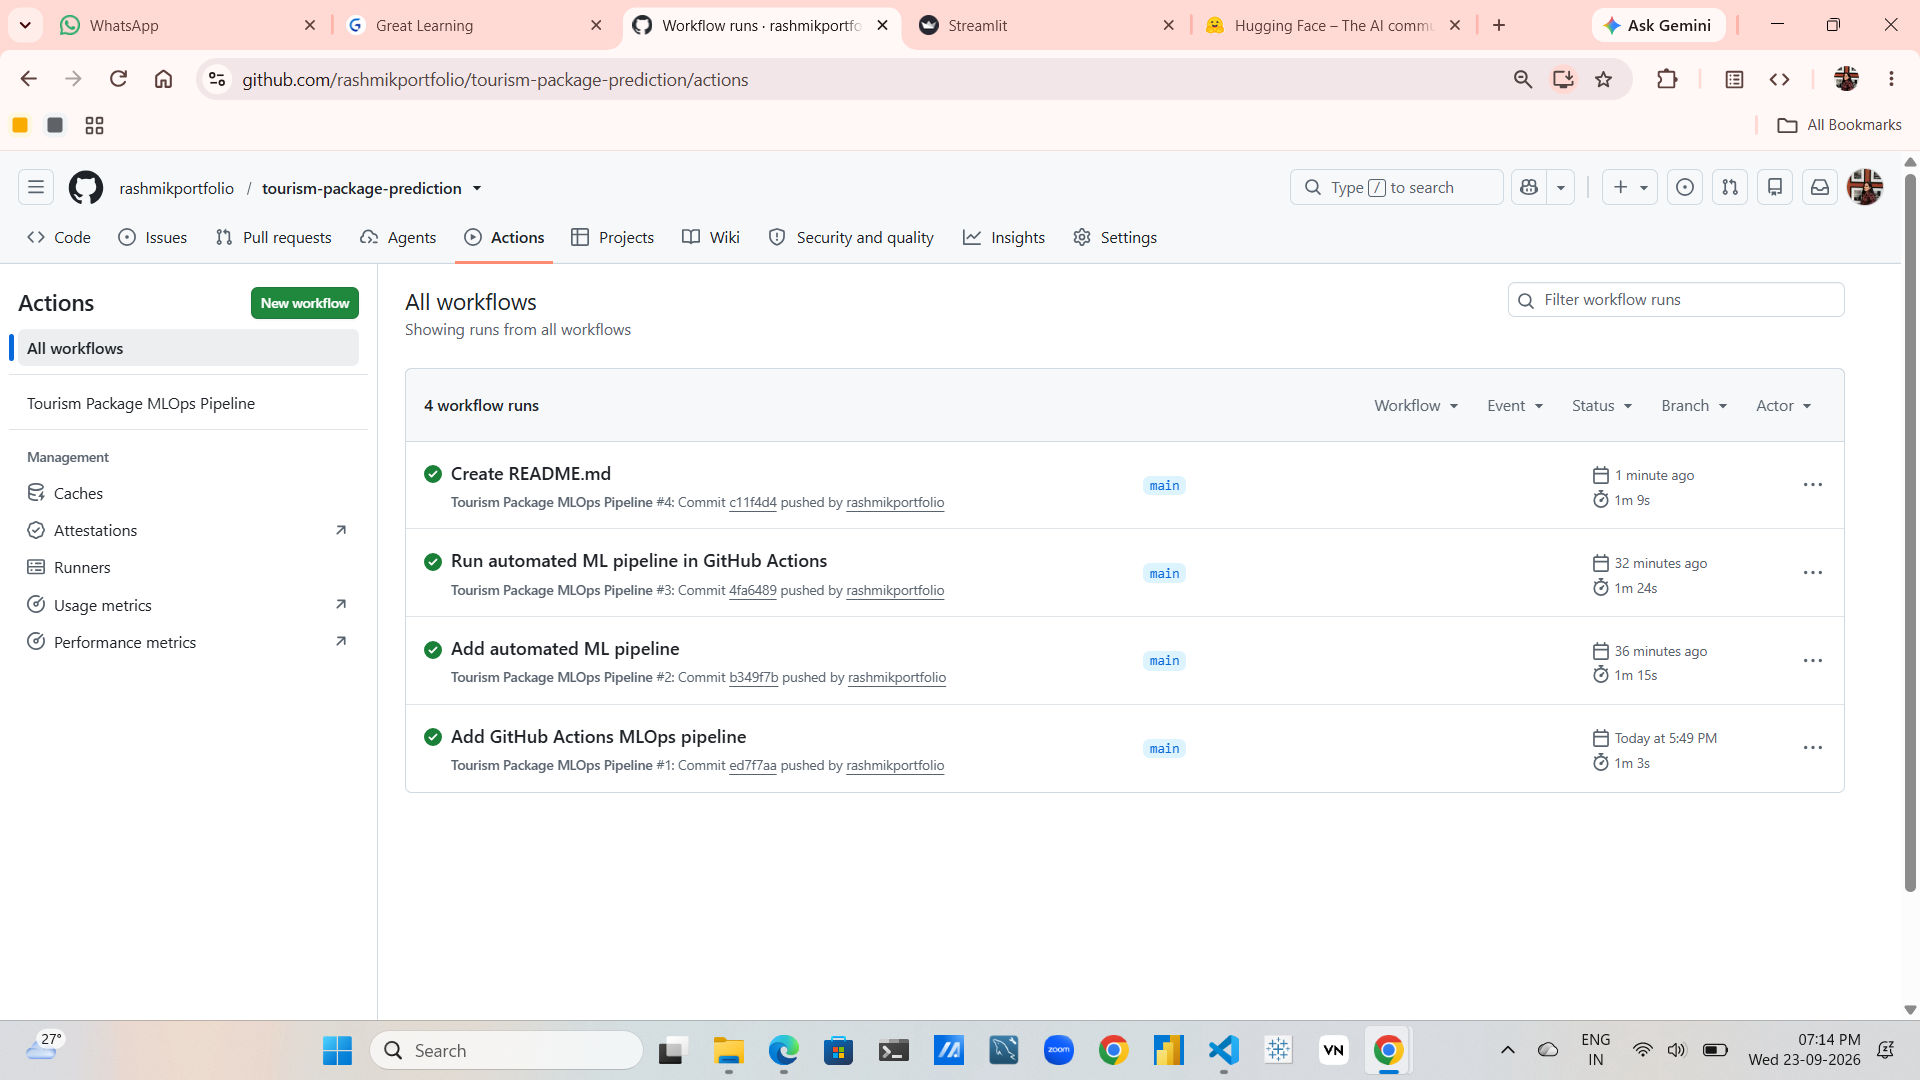


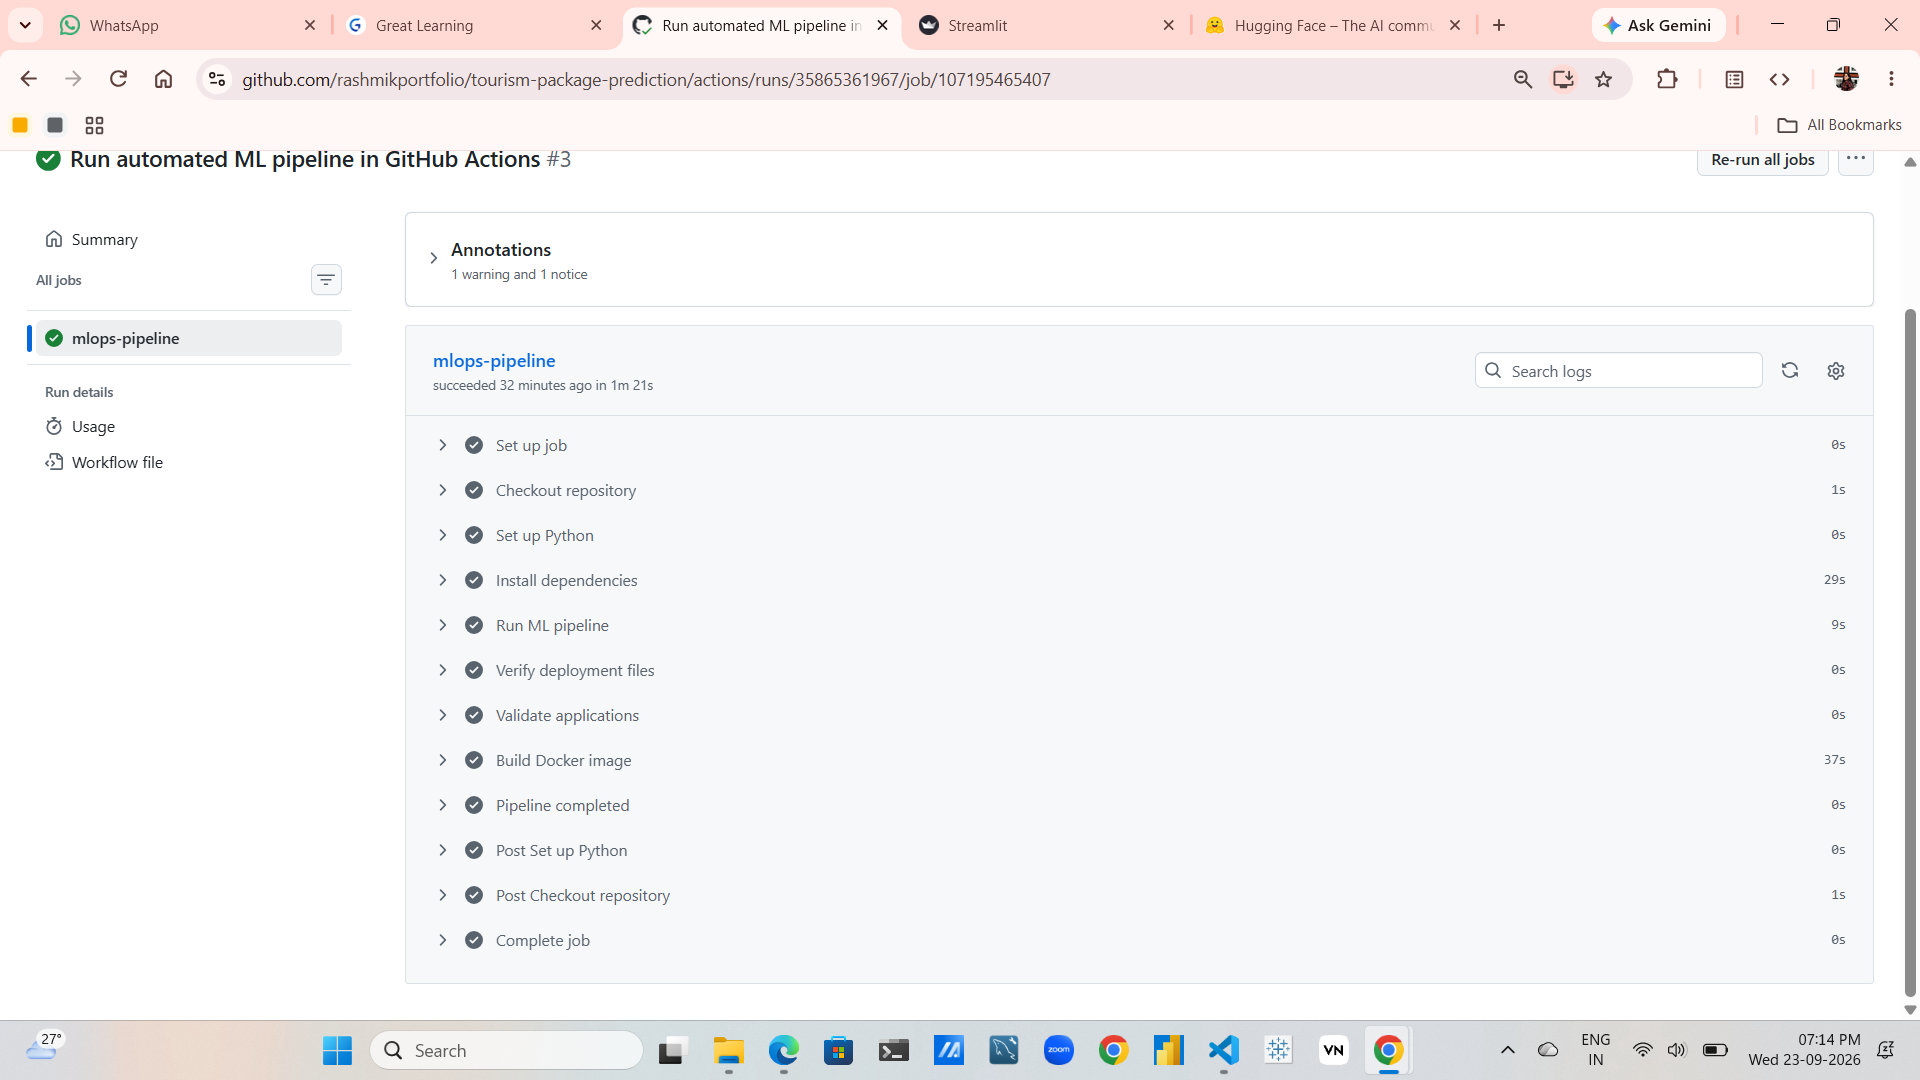


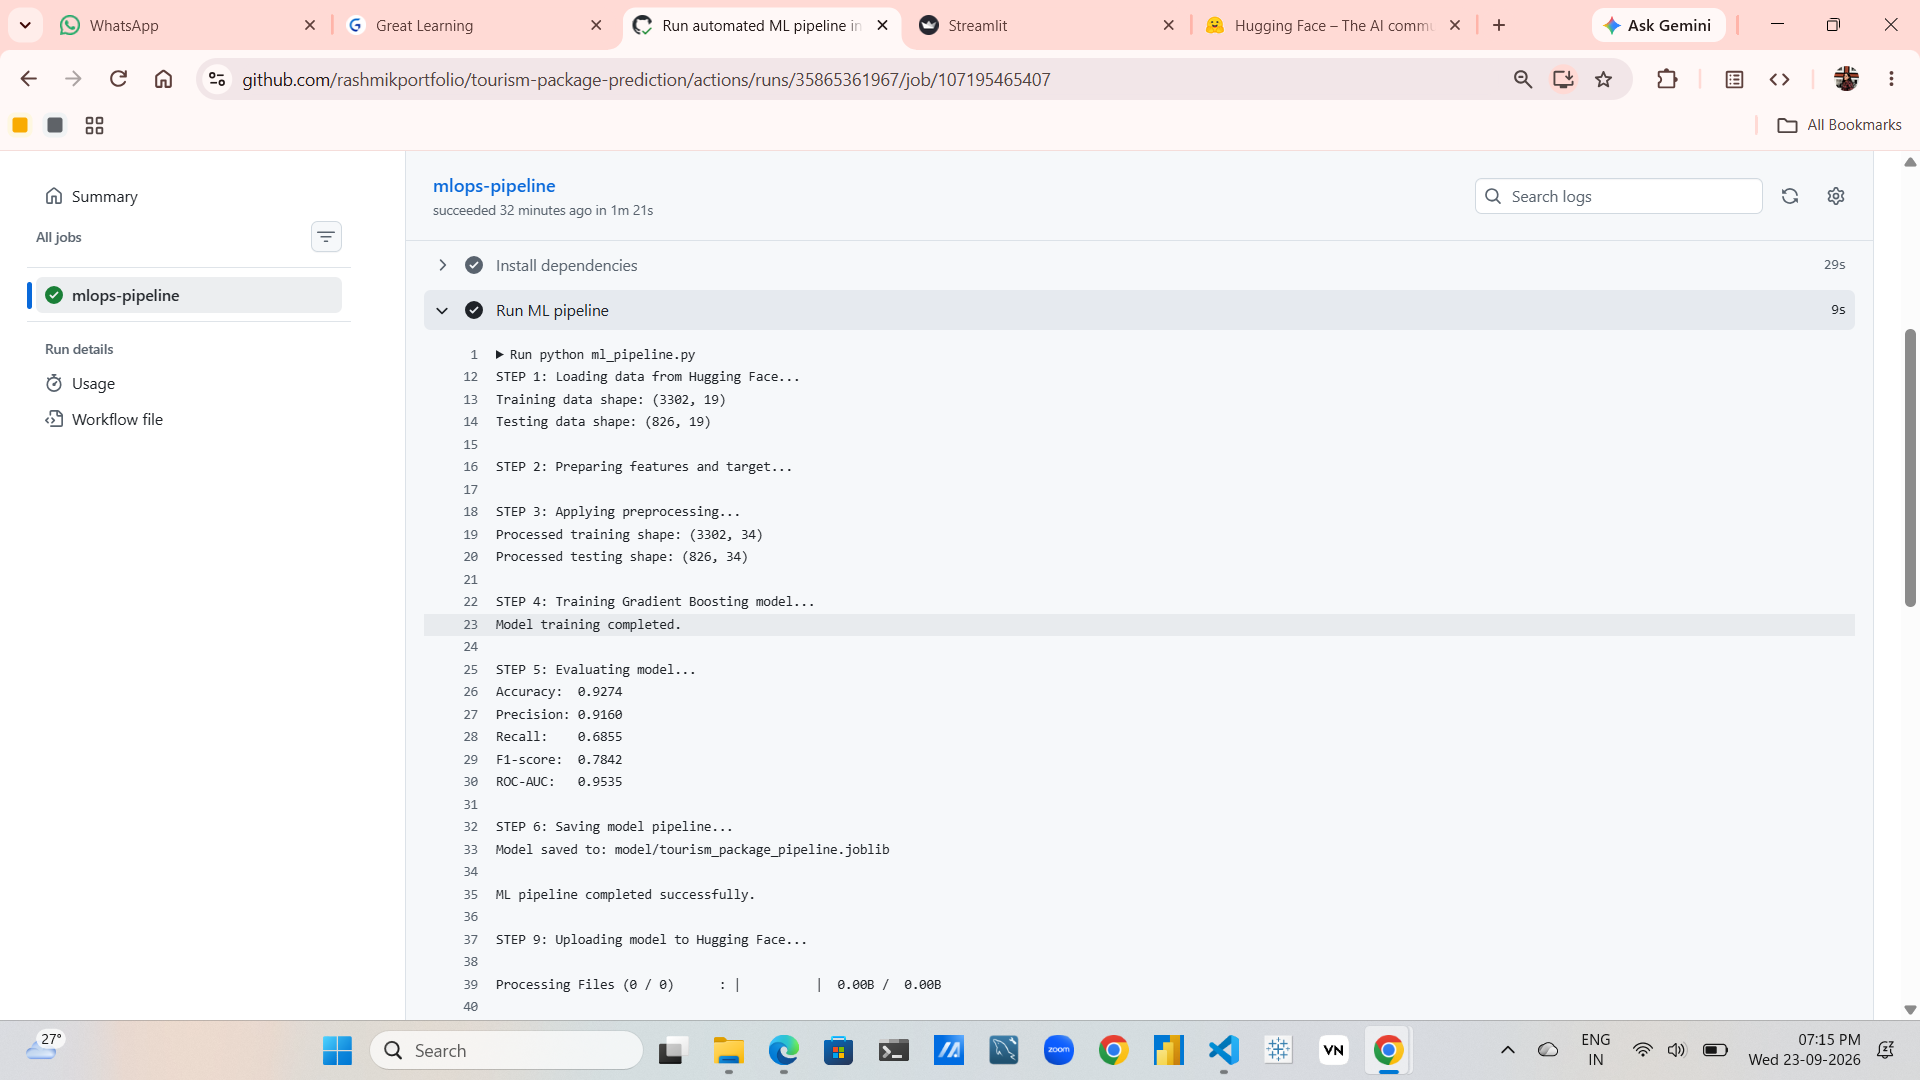


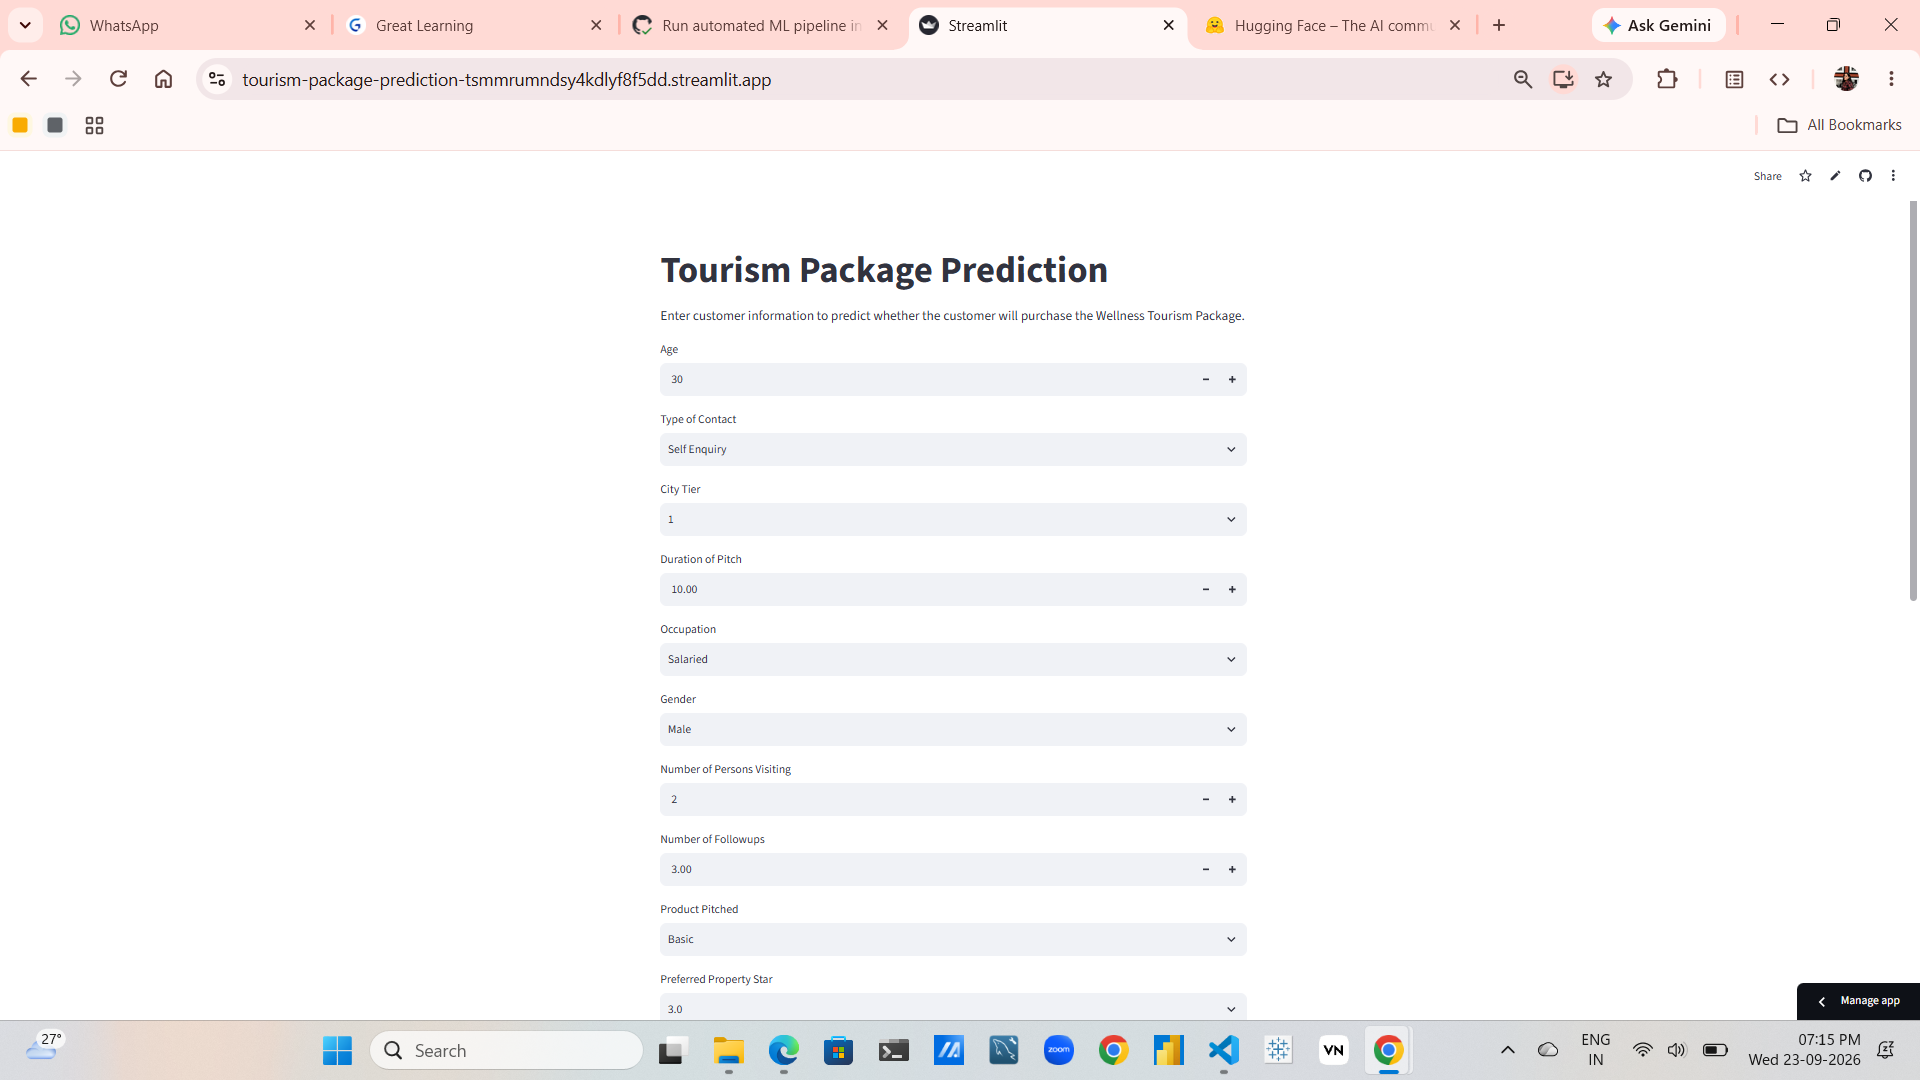


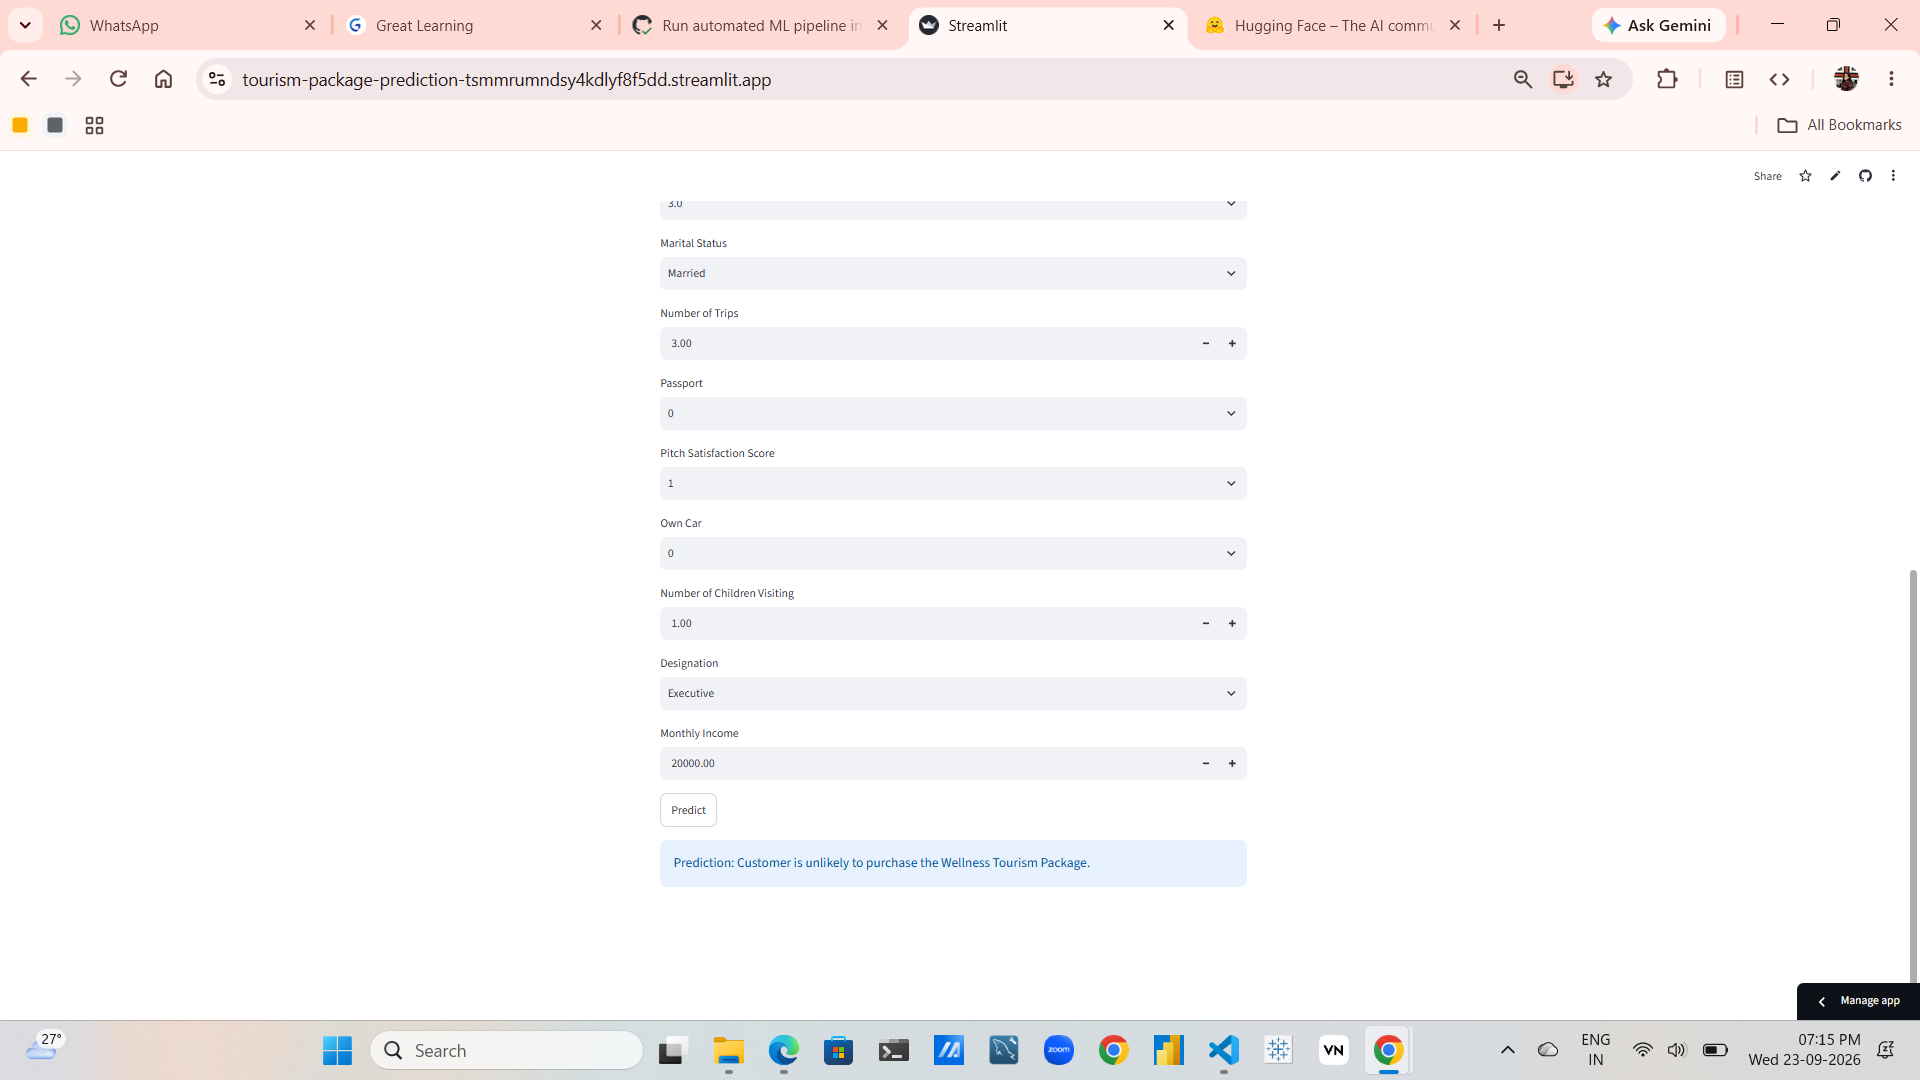


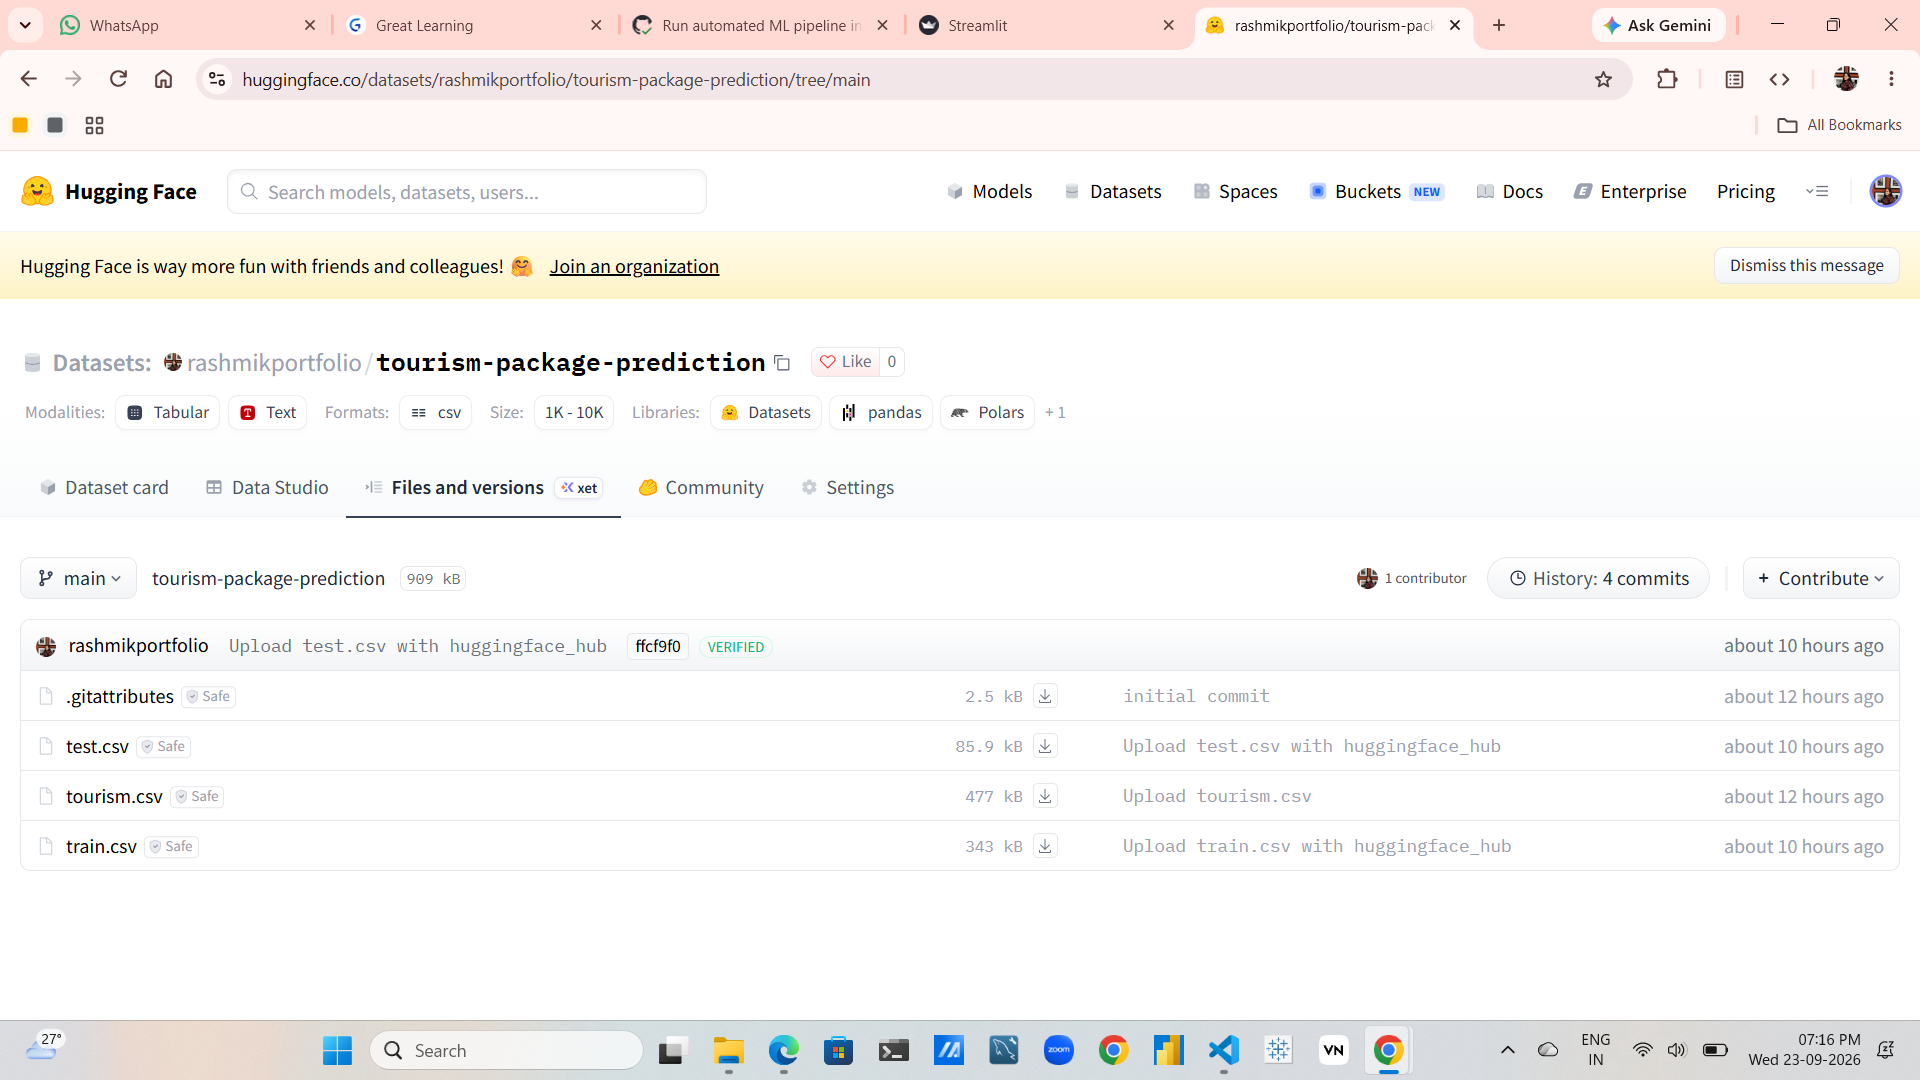


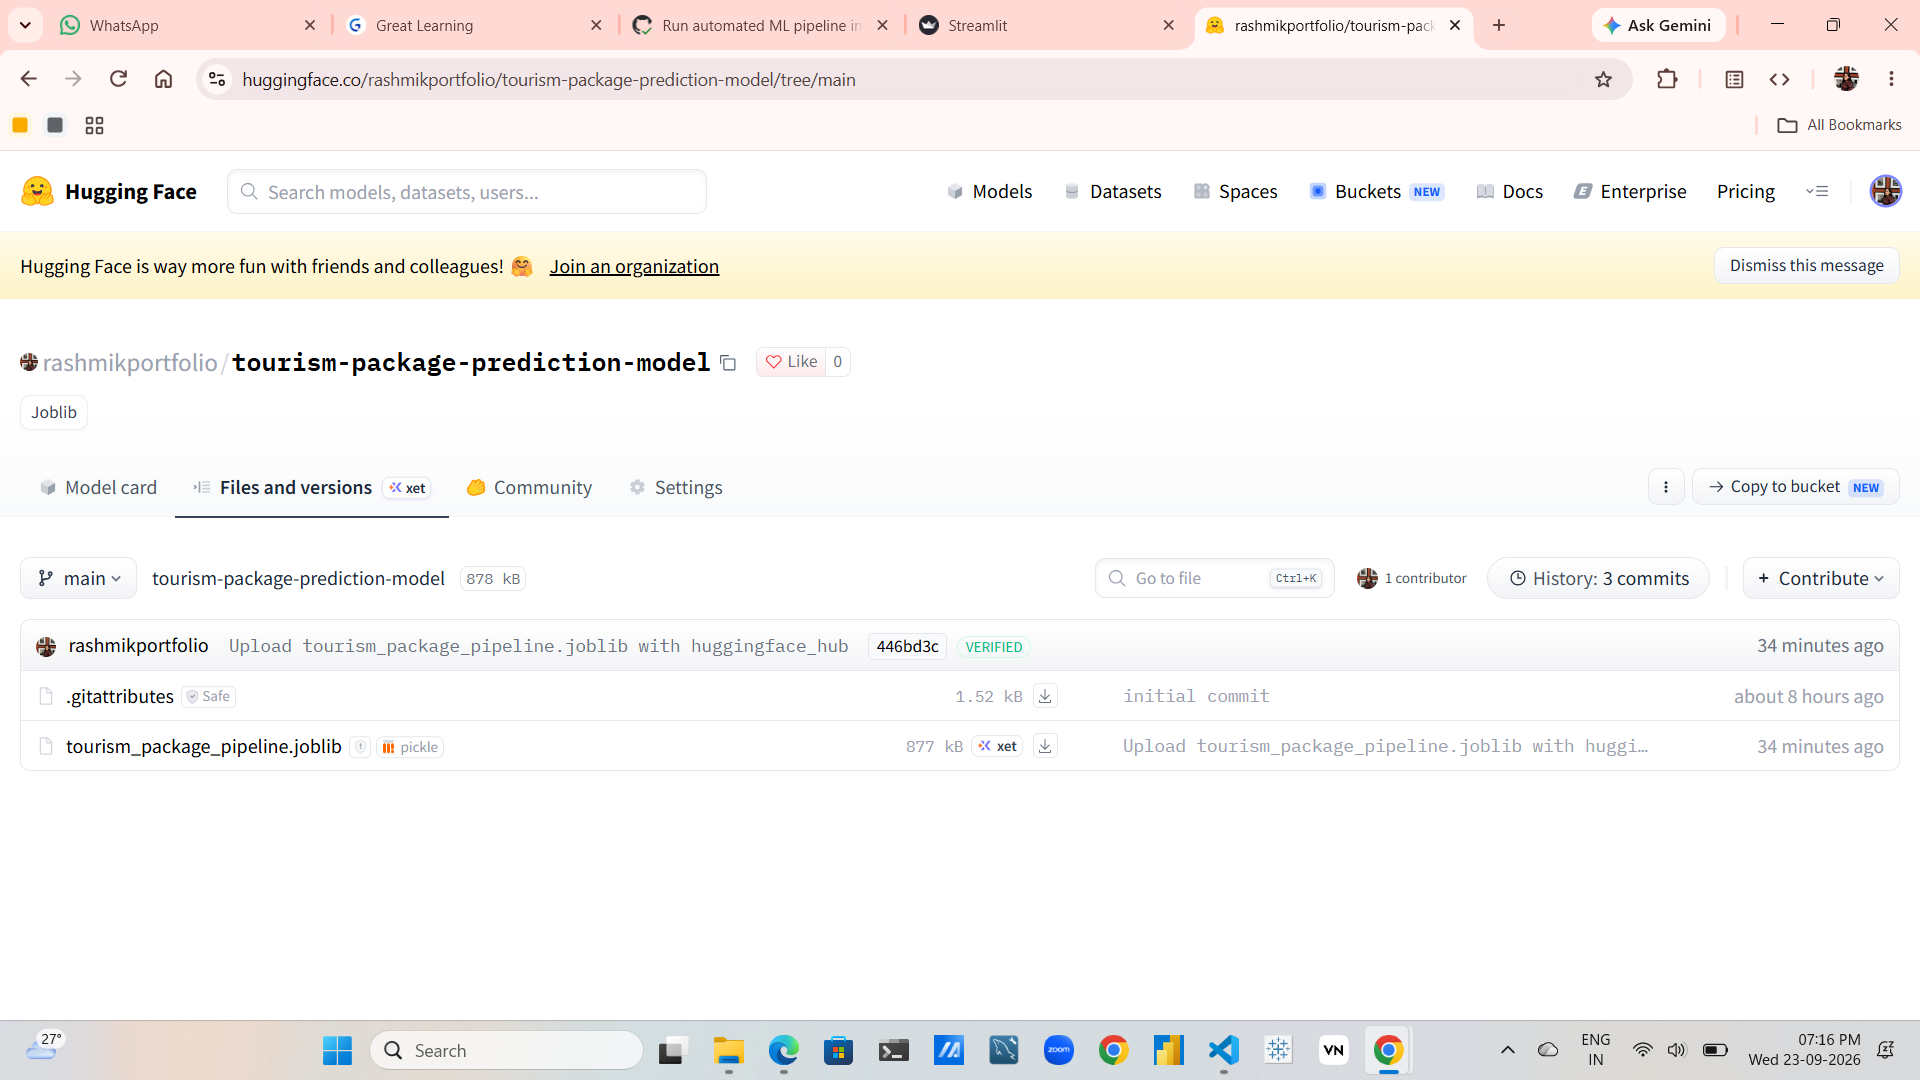

In [2]:
from pathlib import Path
import base64
from IPython.display import display, HTML

image_folder = Path("Images")

def show_image(filename, width=900):
    image_path = image_folder / filename
    
    with open(image_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode()
    
    display(HTML(
        f'<img src="data:image/png;base64,{encoded}" '
        f'style="max-width:{width}px; margin-bottom:20px;">'
    ))

show_image("github repository.png")
show_image("github workflows.png")
show_image("github mlops pipeline.png")
show_image("github run ml pipeline.png")
show_image("streamlit app top.png")
show_image("streamlit app down.png")
show_image("hugging face dataset.png")
show_image("hugging face model.png")

# Final Insights and Project Summary

## Project Overview

This project developed an end-to-end **Tourism Package Purchase Prediction system** using Machine Learning and MLOps practices. The objective was to predict whether a customer would purchase a tourism package (`ProdTaken`) based on demographic, behavioral, and travel-related characteristics.

## Key Project Steps

- **Data Registration:** The tourism dataset was registered and versioned using Hugging Face.
- **Data Preparation:** The dataset was inspected for missing values, duplicates, data types, and class distribution. Categorical variables were standardized and encoded, while numerical features were prepared for modelling.
- **Exploratory Analysis:** Customer characteristics and the distribution of the target variable were examined to understand the dataset and identify relevant patterns.
- **Model Building:** Multiple ensemble and tree-based classification models were trained and evaluated, including:
  - Decision Tree
  - Bagging
  - Random Forest
  - AdaBoost
  - Gradient Boosting
  - XGBoost
- **Experiment Tracking:** Model parameters and evaluation metrics were tracked using **MLflow**.
- **Model Selection:** Gradient Boosting was selected as the final model based on its overall evaluation results, particularly its F1-score and ROC-AUC.
- **Final Model Evaluation:** The final Gradient Boosting model achieved approximately **92.9% accuracy, 78.9% F1-score, and 95.4% ROC-AUC** on the evaluation data.
- **Model Packaging:** The preprocessing steps and trained model were combined into an end-to-end pipeline and saved as a `.joblib` file.
- **Deployment:** The model was connected to a Streamlit application, allowing users to enter customer information and receive a tourism package purchase prediction.
- **MLOps Automation:** GitHub Actions was used to automate dependency installation, model training, evaluation, model deployment to Hugging Face, application validation, and Docker image building.

## Final Insights

The project demonstrates how a machine learning model can be developed beyond experimentation and transformed into a reproducible and deployable application. The use of preprocessing pipelines helps maintain consistency between training and prediction, while MLflow provides experiment tracking and GitHub Actions automates important stages of the workflow.

The final system therefore combines **data preparation, machine learning, experiment tracking, model packaging, deployment, and CI/CD automation** into a single end-to-end MLOps workflow.

## Conclusion

This project provided practical experience in building a complete machine learning lifecycle—from raw tourism data to a deployed prediction application. It demonstrates the integration of **Python, Scikit-learn, MLflow, Hugging Face, Streamlit, Docker, and GitHub Actions** to create a reproducible machine learning solution.